# <img src="https://intelectacup.com/favicon.ico" /> Intelecta Cup - Data Mining Competition 2025  

---

## Informasi Tim
**Nama Tim:** Cognivio

**Institusi:** Politeknik Negeri Malang

| No | Anggota         | Peran                      |
|----|----------------------|----------------------------|
| 1  | Vidi Joshubzky Saviola    | Model Developer   |
| 2  | Cakra Wangsa May Ahmad Widodo             | ML Researcher              |
| 3  | Farrel Augusta Dinata             | ML Researcher Lead              |
| 4  | Hidayat Widi Saputra             | Model Developer   |

---

<div style="text-align:center; font-style:italic; opacity:0.8;">
  © 2025 Cognivio Team. All rights reserved.
</div>

# 0. Preparation

In [1]:
%pip install -q darts

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.3/60.3 kB 2.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.3/46.3 kB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 16.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 200.6/200.6 kB 10.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 825.4/825.4 kB 32.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.7/9.7 MB 92.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 87.2/87.2 kB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 94.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 70.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 37.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211

In [2]:
import os
import sys
import random
from itertools import combinations
from pathlib import Path
import pandas as pd
import numpy as np
from numpy.typing import ArrayLike
import matplotlib.pyplot as plt
import seaborn as sns
import darts
from darts import TimeSeries
from darts.models import (
    LightGBMModel,
    XGBModel,
    RegressionEnsembleModel,
    NaiveDrift,
    NaiveSeasonal,
)
from darts.dataprocessing.transformers import Scaler
from darts.utils.statistics import plot_residuals_analysis
from scipy import stats
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import sklearn
from sklearn.model_selection import (
    train_test_split,
    cross_val_score,
    RandomizedSearchCV,
    TimeSeriesSplit
)
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, LabelEncoder, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.ensemble import (
    RandomForestRegressor,
    GradientBoostingRegressor,
    VotingRegressor,
    RandomForestClassifier
)
from sklearn.metrics import (
    make_scorer,
    mean_absolute_percentage_error,
    root_mean_squared_error
)
from sklearn.pipeline import Pipeline
from sklearn.linear_model import Ridge
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import xgboost
from xgboost import XGBRegressor
import lightgbm
from lightgbm import LGBMRegressor
from IPython.display import display
from typing import Literal, Union, Tuple, Literal


import warnings
warnings.filterwarnings('ignore')

# Detect environment
def detect_environment() -> str:
    """Detect if running in Colab, Kaggle, or local environment"""
    if 'google.colab' in sys.modules:
        return 'colab'
    elif 'kaggle_secrets' in sys.modules or os.environ.get('KAGGLE_KERNEL_RUN_TYPE'):
        return 'kaggle'
    else:
        return 'local'

ENV = detect_environment()
print(f'🔍 Detected environment: {ENV.upper()}')


# setup visualization
sns.set_theme(style='darkgrid', palette='deep')


print(f'Python version: {sys.version}')
print(f'NumPy version: {np.__version__}')
print(f'Pandas version: {pd.__version__}')
print(f'Scikit-learn version: {sklearn.__version__}')
print(f'Darts version: {darts.__version__}')
print(f'XGBoost version: {xgboost.__version__}')
print(f'LightGBM version: {lightgbm.__version__}')

🔍 Detected environment: KAGGLE
Python version: 3.11.13 (main, Jun  4 2025, 08:57:29) [GCC 11.4.0]
NumPy version: 1.26.4
Pandas version: 2.2.3
Scikit-learn version: 1.7.2
Darts version: 0.38.0
XGBoost version: 2.0.3
LightGBM version: 4.6.0


# 1. Dataset Ingestion

In [3]:
def setup_dataset_paths(env: str) -> dict[str, str]:
    """Setup dataset paths based on environment"""

    # Kaggle environment
    if env == 'kaggle':
        return {
            'train_csv': "/kaggle/input/intelecta-cup-data-mining-competition/train.csv",
            'test_csv': "/kaggle/input/intelecta-cup-data-mining-competition/test.csv",
            'save_dir': "/kaggle/working"
        }

    # Local environment
    if env == 'local':
        base_path = "../data" # TODO: Adjust your local environment path
        return {
            'train_csv': f"{base_path}/train.csv",
            'test_csv': f"{base_path}/test.csv",
            'save_dir': f"{base_path}/models"
        }

    # Colab environment
    dataset_name = "intelecta-cup-data-mining-competition"
    local_path = "/content/dataset"
    output_path = "/content/output"

    if not os.path.exists(output_path):
        os.makedirs(output_path)

    # Check if dataset already exists
    if os.path.exists(local_path):
        return {
            'train_csv': f"{local_path}/train.csv",
            'test_csv': f"{local_path}/test.csv",
            'save_dir': output_path
        }

    print("📥 Setting up tabular dataset in Colab...")

    # Setup Kaggle credentials
    _setup_kaggle_credentials()

    # Download and extract dataset
    _download_and_extract_dataset(dataset_name, local_path)

    return {
        'train_csv': f"{local_path}/train.csv",
        'test_csv': f"{local_path}/test.csv",
        'save_dir': output_path
    }

def _setup_kaggle_credentials() -> None:
    """Setup Kaggle credentials in Colab"""
    kaggle_json_drive = "/content/drive/MyDrive/kaggle.json"
    kaggle_json_local = "/root/.kaggle/kaggle.json"

    # Try to copy from Google Drive first
    if os.path.exists(kaggle_json_drive):
        print("📂 Copying kaggle.json from Drive...")
        !mkdir -p /root/.kaggle
        !cp "{kaggle_json_drive}" "{kaggle_json_local}"
        !chmod 600 "{kaggle_json_local}"
        print("✅ Kaggle credentials loaded from Drive")
        return

    # Fallback: manual upload
    print("⚠️ Please upload kaggle.json manually or place it in Drive root folder")
    from google.colab import files  # type: ignore
    uploaded = files.upload()

    for fn in uploaded.keys():
        !mkdir -p /root/.kaggle
        !mv "{fn}" "/root/.kaggle/kaggle.json"
        !chmod 600 "/root/.kaggle/kaggle.json"
        print(f"✅ Kaggle credentials uploaded: {fn}")


def _download_and_extract_dataset(
    dataset_name: str,
    local_path: str
) -> None:
    """Download and extract Kaggle competition dataset"""
    import zipfile

    # Download dataset
    !kaggle competitions download -c {dataset_name} -p /content

    # Extract dataset
    zip_path = f"/content/{dataset_name}.zip"
    if not os.path.exists(zip_path):
        raise FileNotFoundError(f"Dataset zip not found: {zip_path}")

    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(local_path)

    print(f"✅ Dataset extracted to {local_path}")

# Setup paths
paths = setup_dataset_paths(ENV)
print(f"📁 Dataset paths configured for {ENV}:")
for key, path in paths.items():
    exists = "✅" if os.path.exists(path) else "⚠️"
    print(f"   {key}: {path} {exists}")

# Create save directory
os.makedirs(paths['save_dir'], exist_ok=True)

# Set random seed for reproducibility
def set_seed(seed: int = 20) -> None:
    random.seed(seed)
    np.random.seed(seed)

RANDOM_SEED = 20
set_seed(seed=RANDOM_SEED)




print('Load dataset from CSV to Pandas DataFrame')
df = pd.read_csv(paths['train_csv'])

display(df.head(20))
display(df.describe())
display(df.info())

📁 Dataset paths configured for kaggle:
   train_csv: /kaggle/input/intelecta-cup-data-mining-competition/train.csv ✅
   test_csv: /kaggle/input/intelecta-cup-data-mining-competition/test.csv ✅
   save_dir: /kaggle/working ✅
Load dataset from CSV to Pandas DataFrame


,ID,Tahun,Nama_Negara,Wilayah,Jenis_Tanaman,Total_Curah_Hujan_mm,Emisi_CO2_JT_Ton,Hasil_Panen_Ton_per_HA,Kejadian_Cuaca_Ekstrim,Akses_Irigasi,Penggunaan_Pestisida_KG_per_HA,Penggunaan_Pupuk_KG_per_HA,Indeks_Kesehatan_Tanah,Strategi_Adaptasi,Suhu_Rata_Rata_C
0,0,2015,USA,South,Soybeans,1658.71,13.36,2.620,10,74.41,38.97,2.64,46.07,Manajemen Air,20.43
1,1,2022,China,East,Wheat,1478.74,9.55,0.570,2,36.90,49.99,77.22,88.87,Rotasi Tanaman,-0.33
2,2,2000,India,'West Bengal',Fruits,1252.34,27.37,2.115,3,34.21,2.75,83.94,77.15,Pertanian Organik,12.97
3,3,2008,Nigeria,'North West',Sugarcane,209.89,16.16,4.158,5,91.74,36.80,37.50,73.59,Pertanian Organik,12.81
4,4,1991,Canada,Ontario,Vegetables,1086.67,3.71,2.430,0,14.72,7.22,28.72,41.90,Tanpa Adaptasi,4.22
5,5,1990,Australia,Queensland,Fruits,2265.29,2.33,2.030,4,79.39,48.80,3.30,77.63,Tanpa Adaptasi,14.70
6,6,2017,Russia,Northwestern,Rice,586.35,7.00,1.070,10,88.96,42.20,71.15,45.82,Tanaman Tahan Kekeringan,7.34
7,7,1995,China,Central,Vegetables,2281.25,24.21,2.907,1,27.44,23.94,13.96,50.97,Tanaman Tahan Kekeringan,16.97
8,8,2016,France,'Provence-Alpes-Cote d’Azur',NaN,792.07,10.31,3.420,1,51.51,4.60,75.99,94.94,Pertanian Organik,30.23
9,9,1991,Nigeria,'North West',Cotton,1746.26,25.28,2.772,7,39.09,9.33,90.96,59.65,Manajemen Air,20.30


,ID,Tahun,Total_Curah_Hujan_mm,Emisi_CO2_JT_Ton,Hasil_Panen_Ton_per_HA,Kejadian_Cuaca_Ekstrim,Akses_Irigasi,Penggunaan_Pestisida_KG_per_HA,Penggunaan_Pupuk_KG_per_HA,Indeks_Kesehatan_Tanah,Suhu_Rata_Rata_C
count,8000.00000,8000.000000,7821.000000,8000.000000,7800.000000,8000.000000,7819.000000,8000.000000,8000.000000,8000.000000,8000.000000
mean,3999.50000,2007.032750,1615.503060,15.271184,2.238219,4.989750,55.394575,24.920015,49.706654,64.824446,15.206680
std,2309.54541,10.106035,807.932322,8.551214,0.996626,3.171814,26.034847,14.454507,28.674985,20.153617,11.490611
min,0.00000,1990.000000,200.170000,0.500000,0.450000,0.000000,10.010000,0.000000,0.030000,30.000000,-4.990000
25%,1999.75000,1998.000000,929.290000,7.860000,1.449000,2.000000,32.905000,12.550000,25.160000,47.115000,5.377500
50%,3999.50000,2007.000000,1614.790000,15.250000,2.170000,5.000000,55.340000,24.930000,49.270000,64.675000,15.140000
75%,5999.25000,2016.000000,2316.820000,22.820000,2.930000,8.000000,77.770000,37.382500,74.430000,82.302500,25.340000
max,7999.00000,2024.000000,2999.670000,30.000000,5.000000,10.000000,99.990000,49.990000,99.990000,100.000000,35.000000


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8000 entries, 0 to 7999
Data columns (total 15 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   ID                              8000 non-null   int64  
 1   Tahun                           8000 non-null   int64  
 2   Nama_Negara                     8000 non-null   object 
 3   Wilayah                         8000 non-null   object 
 4   Jenis_Tanaman                   7781 non-null   object 
 5   Total_Curah_Hujan_mm            7821 non-null   float64
 6   Emisi_CO2_JT_Ton                8000 non-null   float64
 7   Hasil_Panen_Ton_per_HA          7800 non-null   float64
 8   Kejadian_Cuaca_Ekstrim          8000 non-null   int64  
 9   Akses_Irigasi                   7819 non-null   float64
 10  Penggunaan_Pestisida_KG_per_HA  8000 non-null   float64
 11  Penggunaan_Pupuk_KG_per_HA      8000 non-null   float64
 12  Indeks_Kesehatan_Tanah          80

None

# 2. Exploratory Data Analysis (EDA)

## 2.1 Checking Correlation between Each Features


Pengecekan korelasi antar fitur berfungsi untuk mengetahui hubungan antar fitur dan seberapa kuat hubungan tersebut mempengaruhi satu sama lain.

### 2.1.1 Numeric-numeric features

Hasil pearson correlation matrix:                                     Tahun  Total_Curah_Hujan_mm  \
Tahun                           1.000000              0.012556   
Total_Curah_Hujan_mm            0.012556              1.000000   
Emisi_CO2_JT_Ton               -0.005061             -0.007133   
Hasil_Panen_Ton_per_HA         -0.001188              0.023763   
Kejadian_Cuaca_Ekstrim          0.000736              0.004888   
Akses_Irigasi                  -0.007673             -0.013014   
Penggunaan_Pestisida_KG_per_HA -0.003620              0.004846   
Penggunaan_Pupuk_KG_per_HA      0.021150             -0.020502   
Indeks_Kesehatan_Tanah         -0.006140             -0.018602   
Suhu_Rata_Rata_C               -0.008861              0.008695   

                                Emisi_CO2_JT_Ton  Hasil_Panen_Ton_per_HA  \
Tahun                                  -0.005061               -0.001188   
Total_Curah_Hujan_mm                   -0.007133                0.023763   
Emisi_CO2_

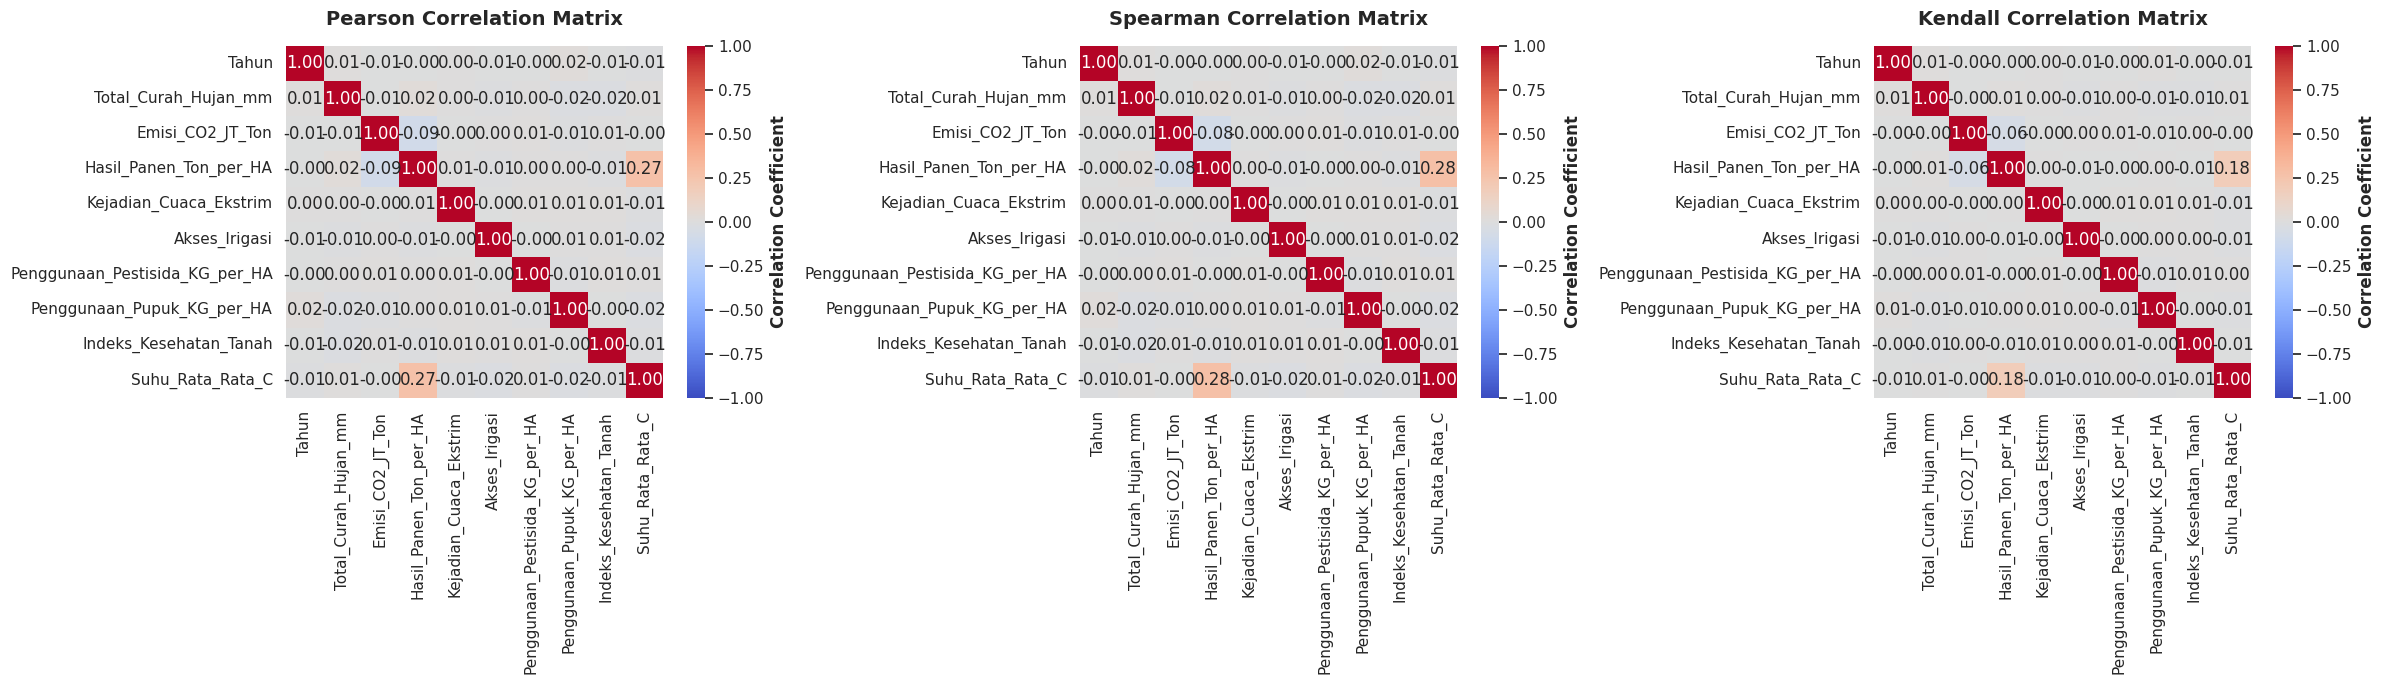

In [4]:
numeric_df = df.select_dtypes(include=[np.number]).drop(columns=['ID'])

# Compute correlation matrix
pearson_corr_matrix = numeric_df.corr(method='pearson')
spearman_corr_matrix = numeric_df.corr(method='spearman')
kendall_corr_matrix = numeric_df.corr(method='kendall')

# Display matrix
print('Hasil pearson correlation matrix: ', pearson_corr_matrix)
print('\nHasil spearman correlation matrix: ', spearman_corr_matrix)
print('\nHasil kendall correlation matrix: ', kendall_corr_matrix)

# Create figure with 3 subplots
fig, axes = plt.subplots(1, 3, figsize=(24, 7))

# Plot Pearson correlation
sns.heatmap(pearson_corr_matrix, annot=True, fmt=".2f", cmap="coolwarm",
            center=0, vmin=-1, vmax=1, ax=axes[0],
            cbar_kws={'label': 'Correlation Coefficient'})
axes[0].set_title("Pearson Correlation Matrix", fontsize=14, fontweight='bold', pad=15)

# Plot Spearman correlation
sns.heatmap(spearman_corr_matrix, annot=True, fmt=".2f", cmap="coolwarm",
            center=0, vmin=-1, vmax=1, ax=axes[1],
            cbar_kws={'label': 'Correlation Coefficient'})
axes[1].set_title("Spearman Correlation Matrix", fontsize=14, fontweight='bold', pad=15)

# Plot Kendall correlation
sns.heatmap(kendall_corr_matrix, annot=True, fmt=".2f", cmap="coolwarm",
            center=0, vmin=-1, vmax=1, ax=axes[2],
            cbar_kws={'label': 'Correlation Coefficient'})
axes[2].set_title("Kendall Correlation Matrix", fontsize=14, fontweight='bold', pad=15)

plt.tight_layout()
plt.show()

### 2.1.2 Numeric-categorical features

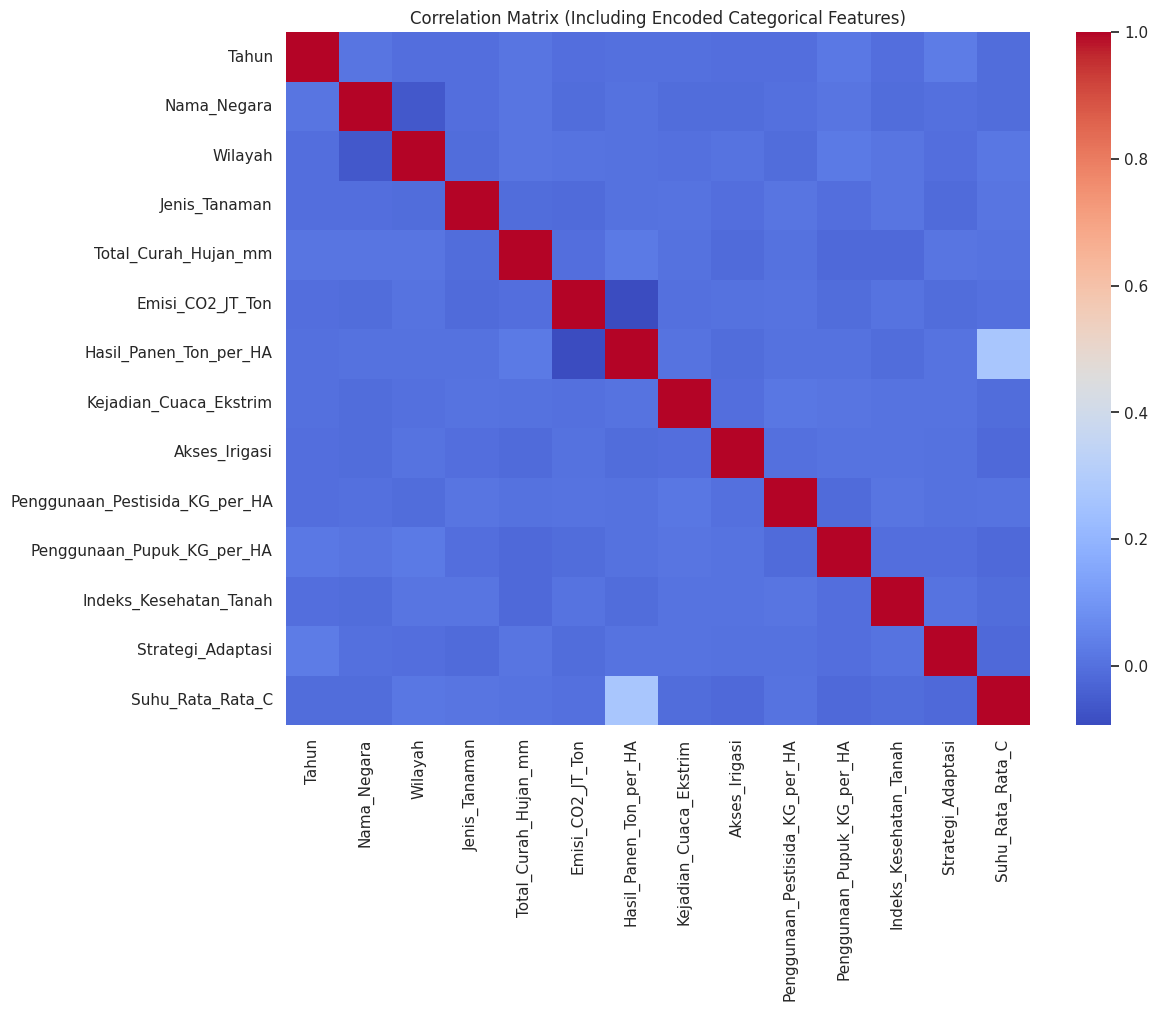

In [5]:
df_encoded = df.copy()
df_encoded = df_encoded.drop(columns=['ID'])

for col in df_encoded.select_dtypes(include='object').columns:
    le = LabelEncoder()
    df_encoded[col] = le.fit_transform(df_encoded[col].astype(str))

corr_matrix = df_encoded.corr()
plt.figure(figsize=(12,9))
sns.heatmap(corr_matrix, cmap="coolwarm", annot=False)
plt.title("Correlation Matrix (Including Encoded Categorical Features)")
plt.show()

### 2.1.3 Linearity Correlation

#### Numeric-numeric features

Total pairs: 45


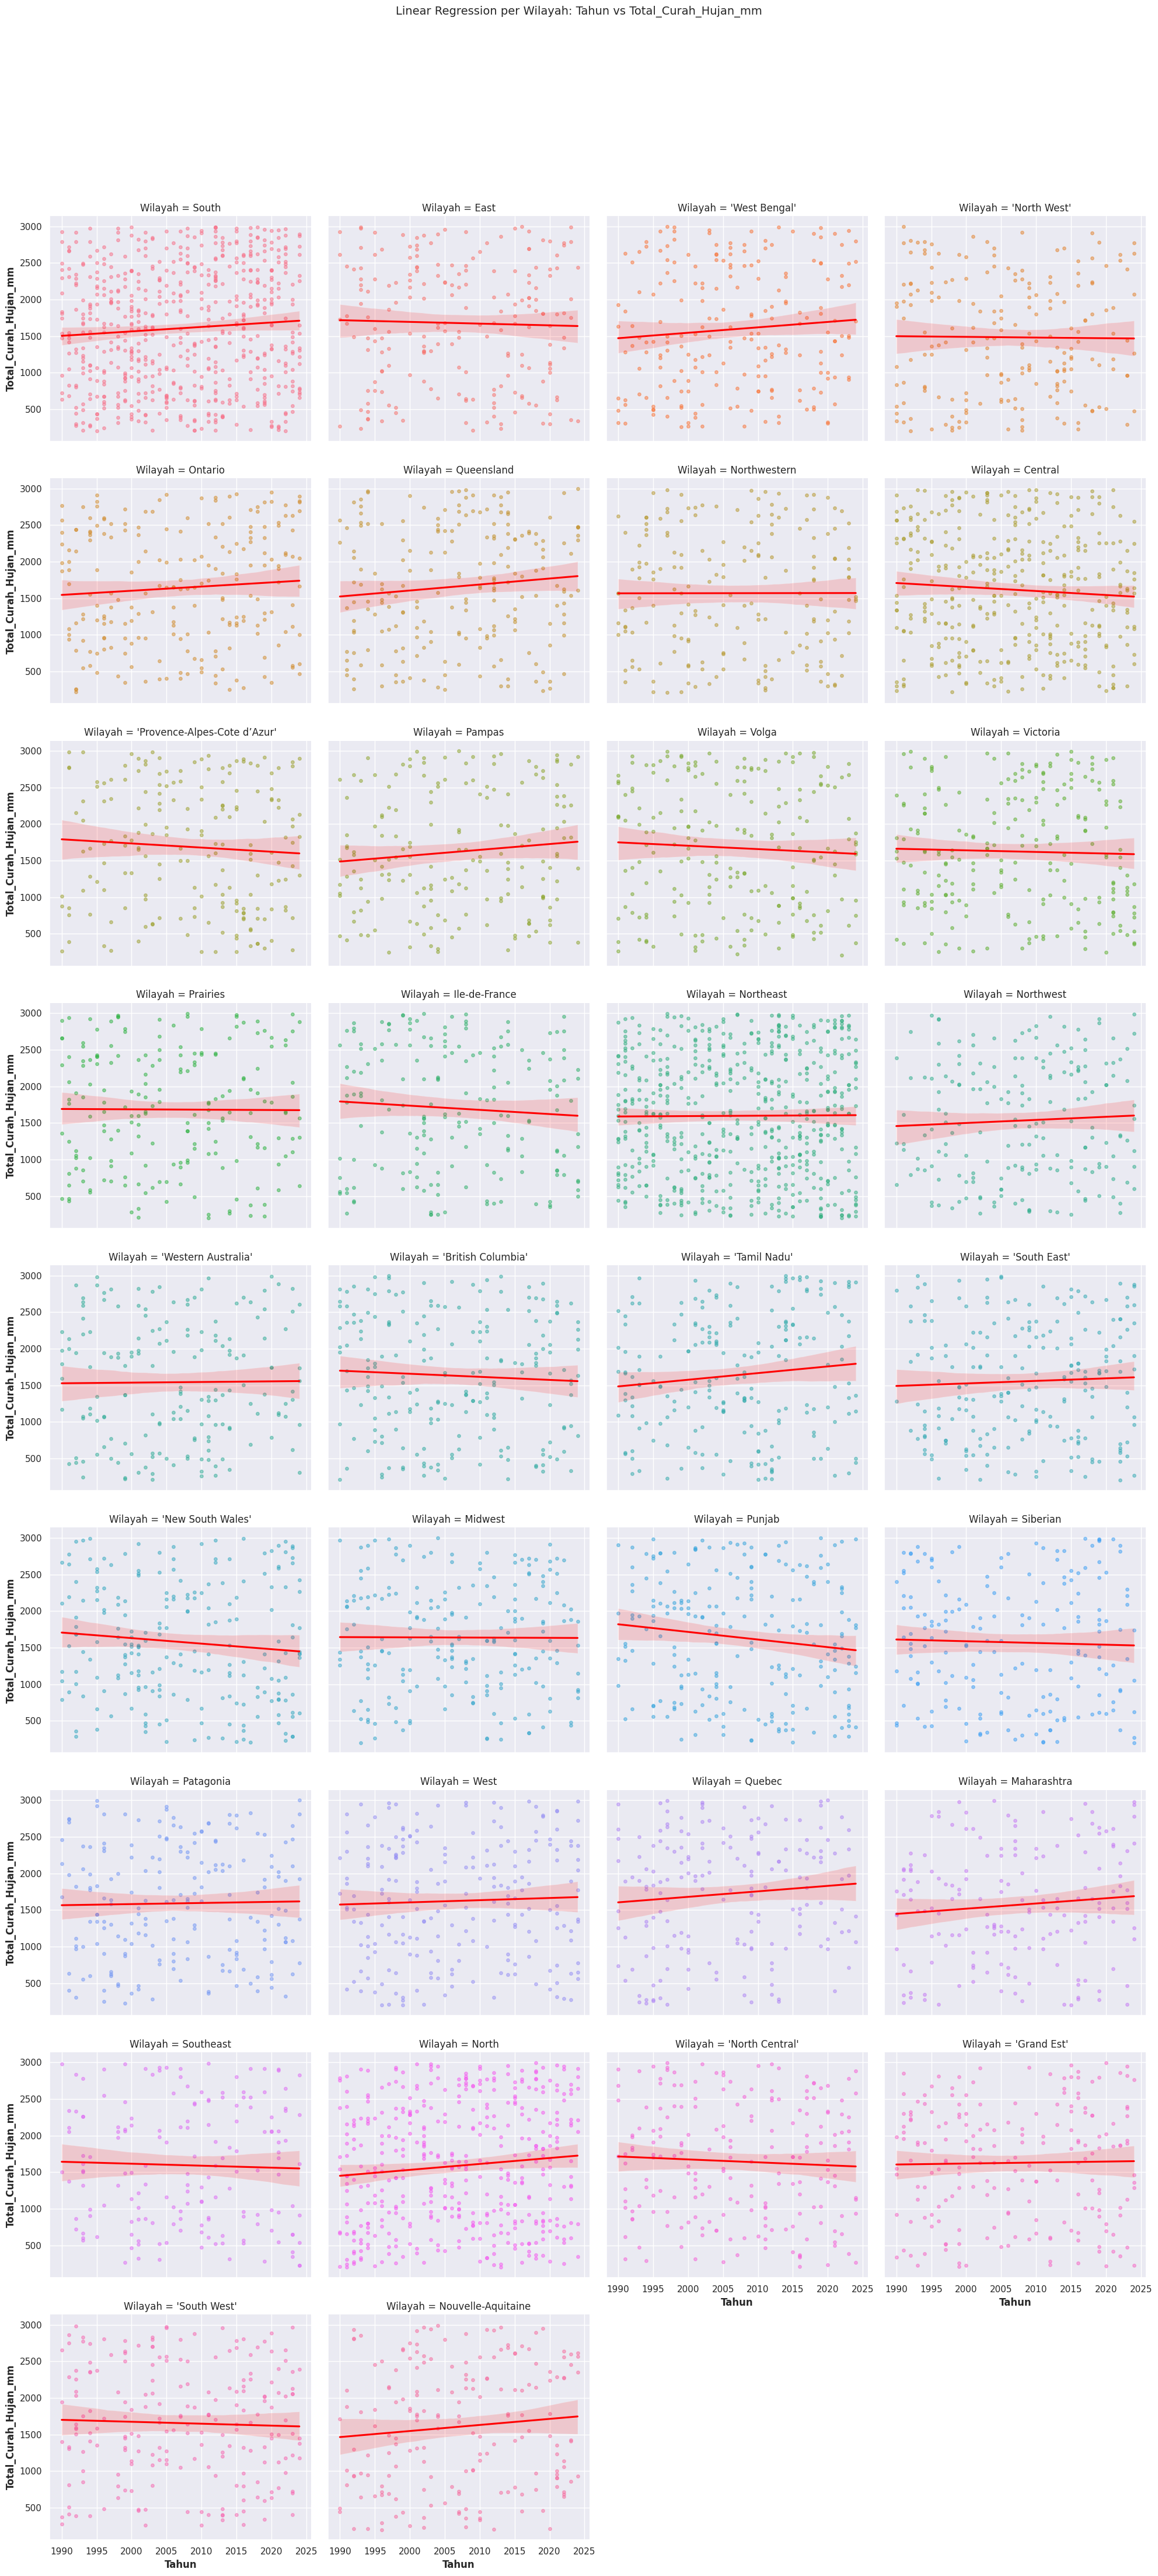

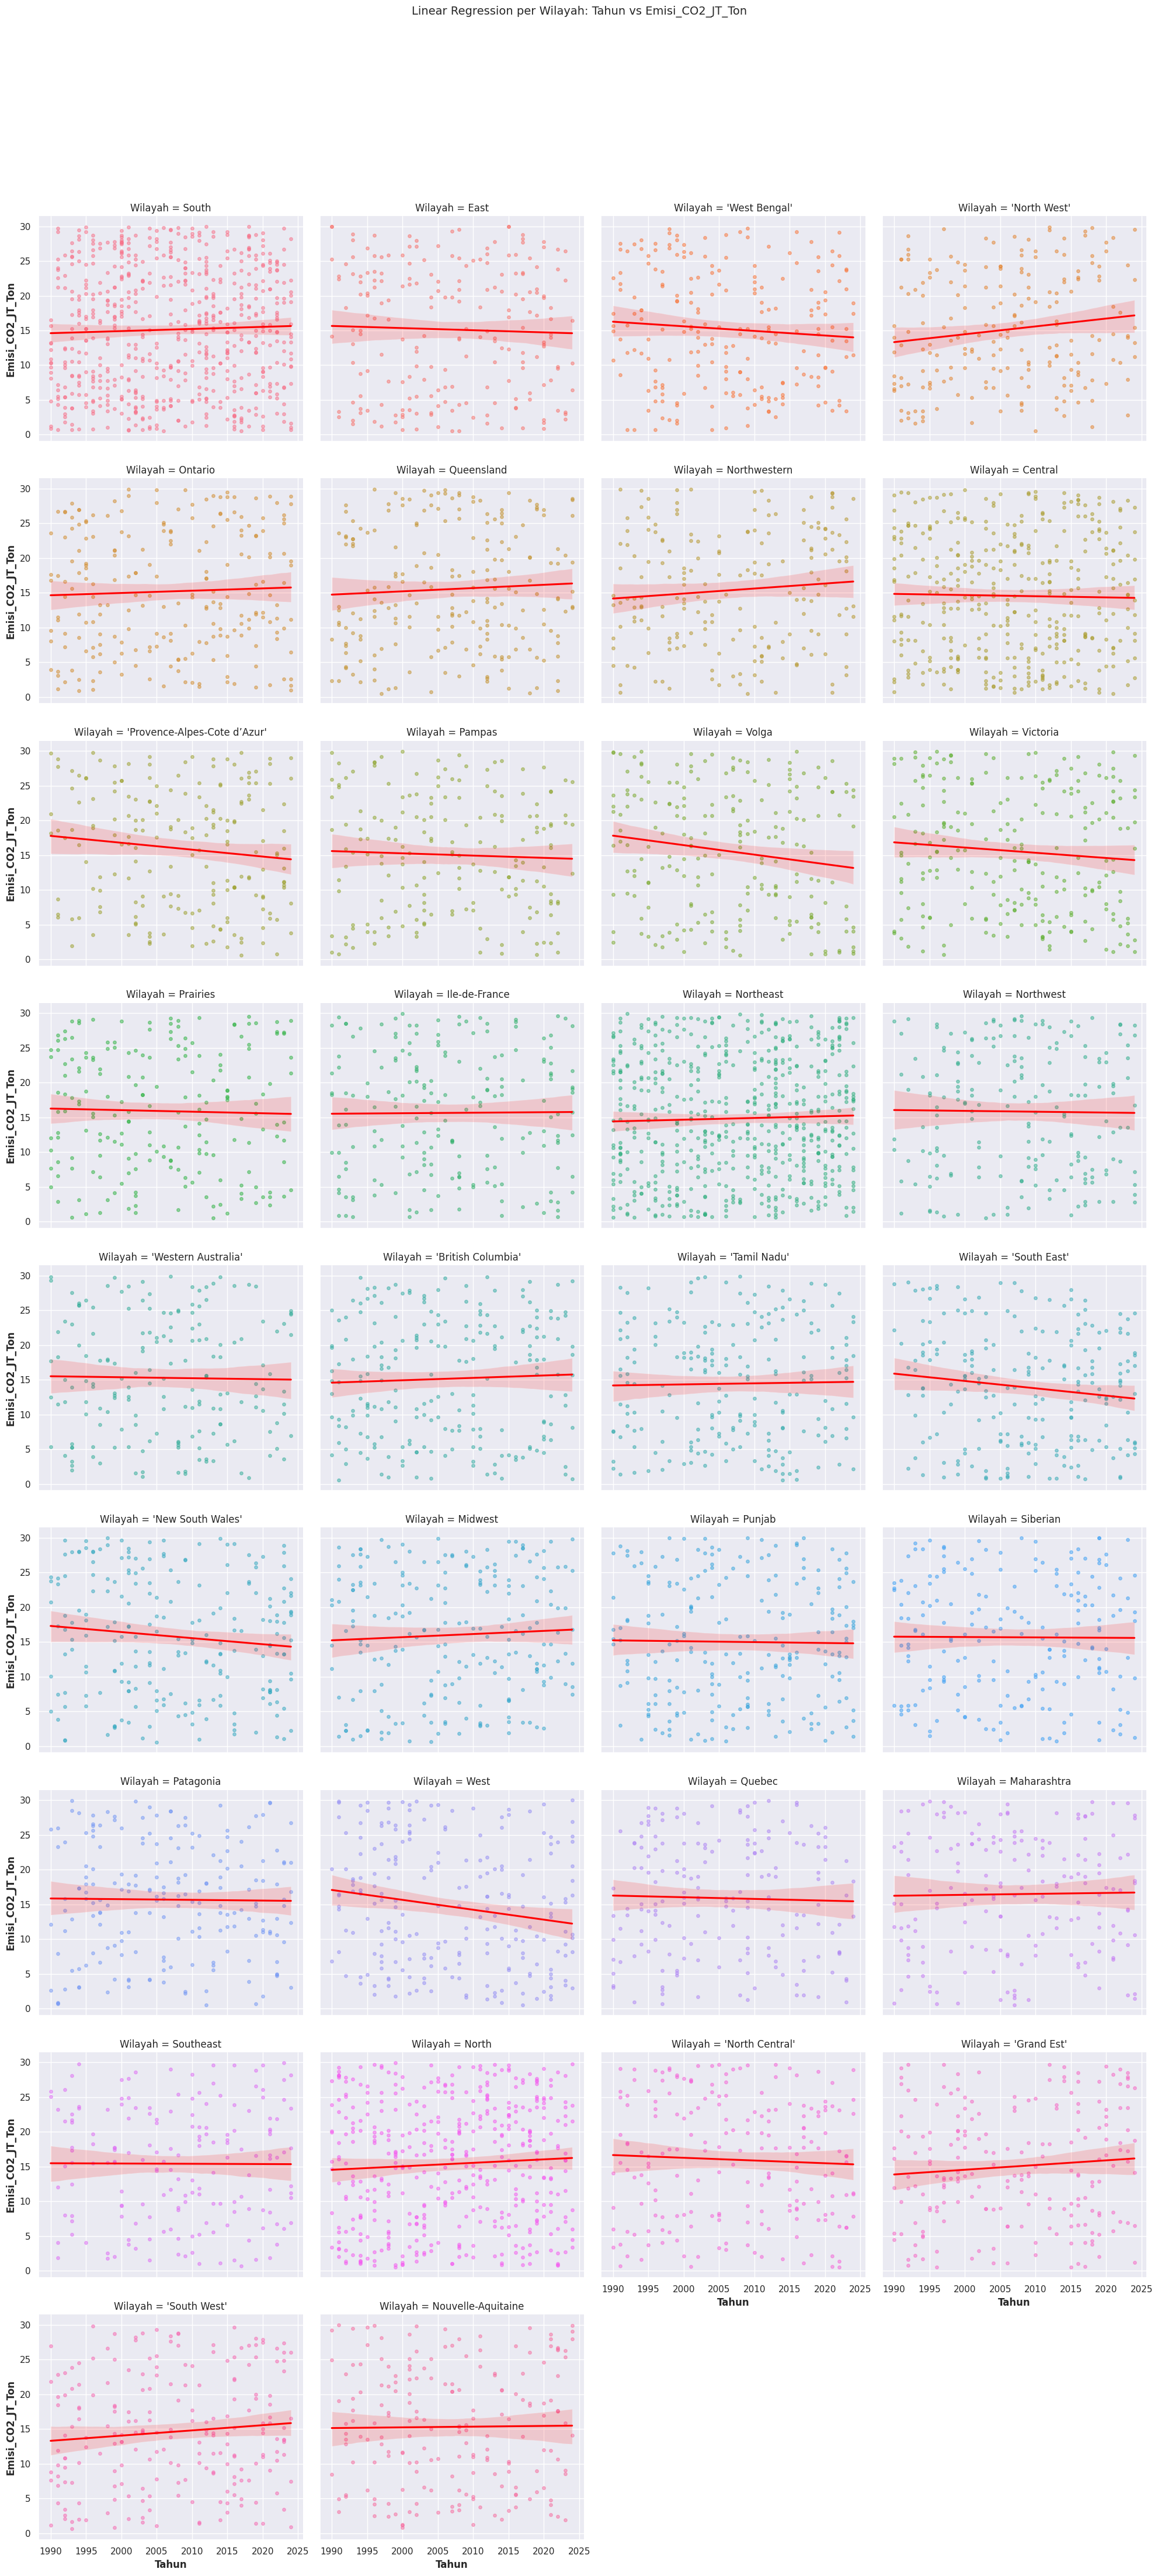

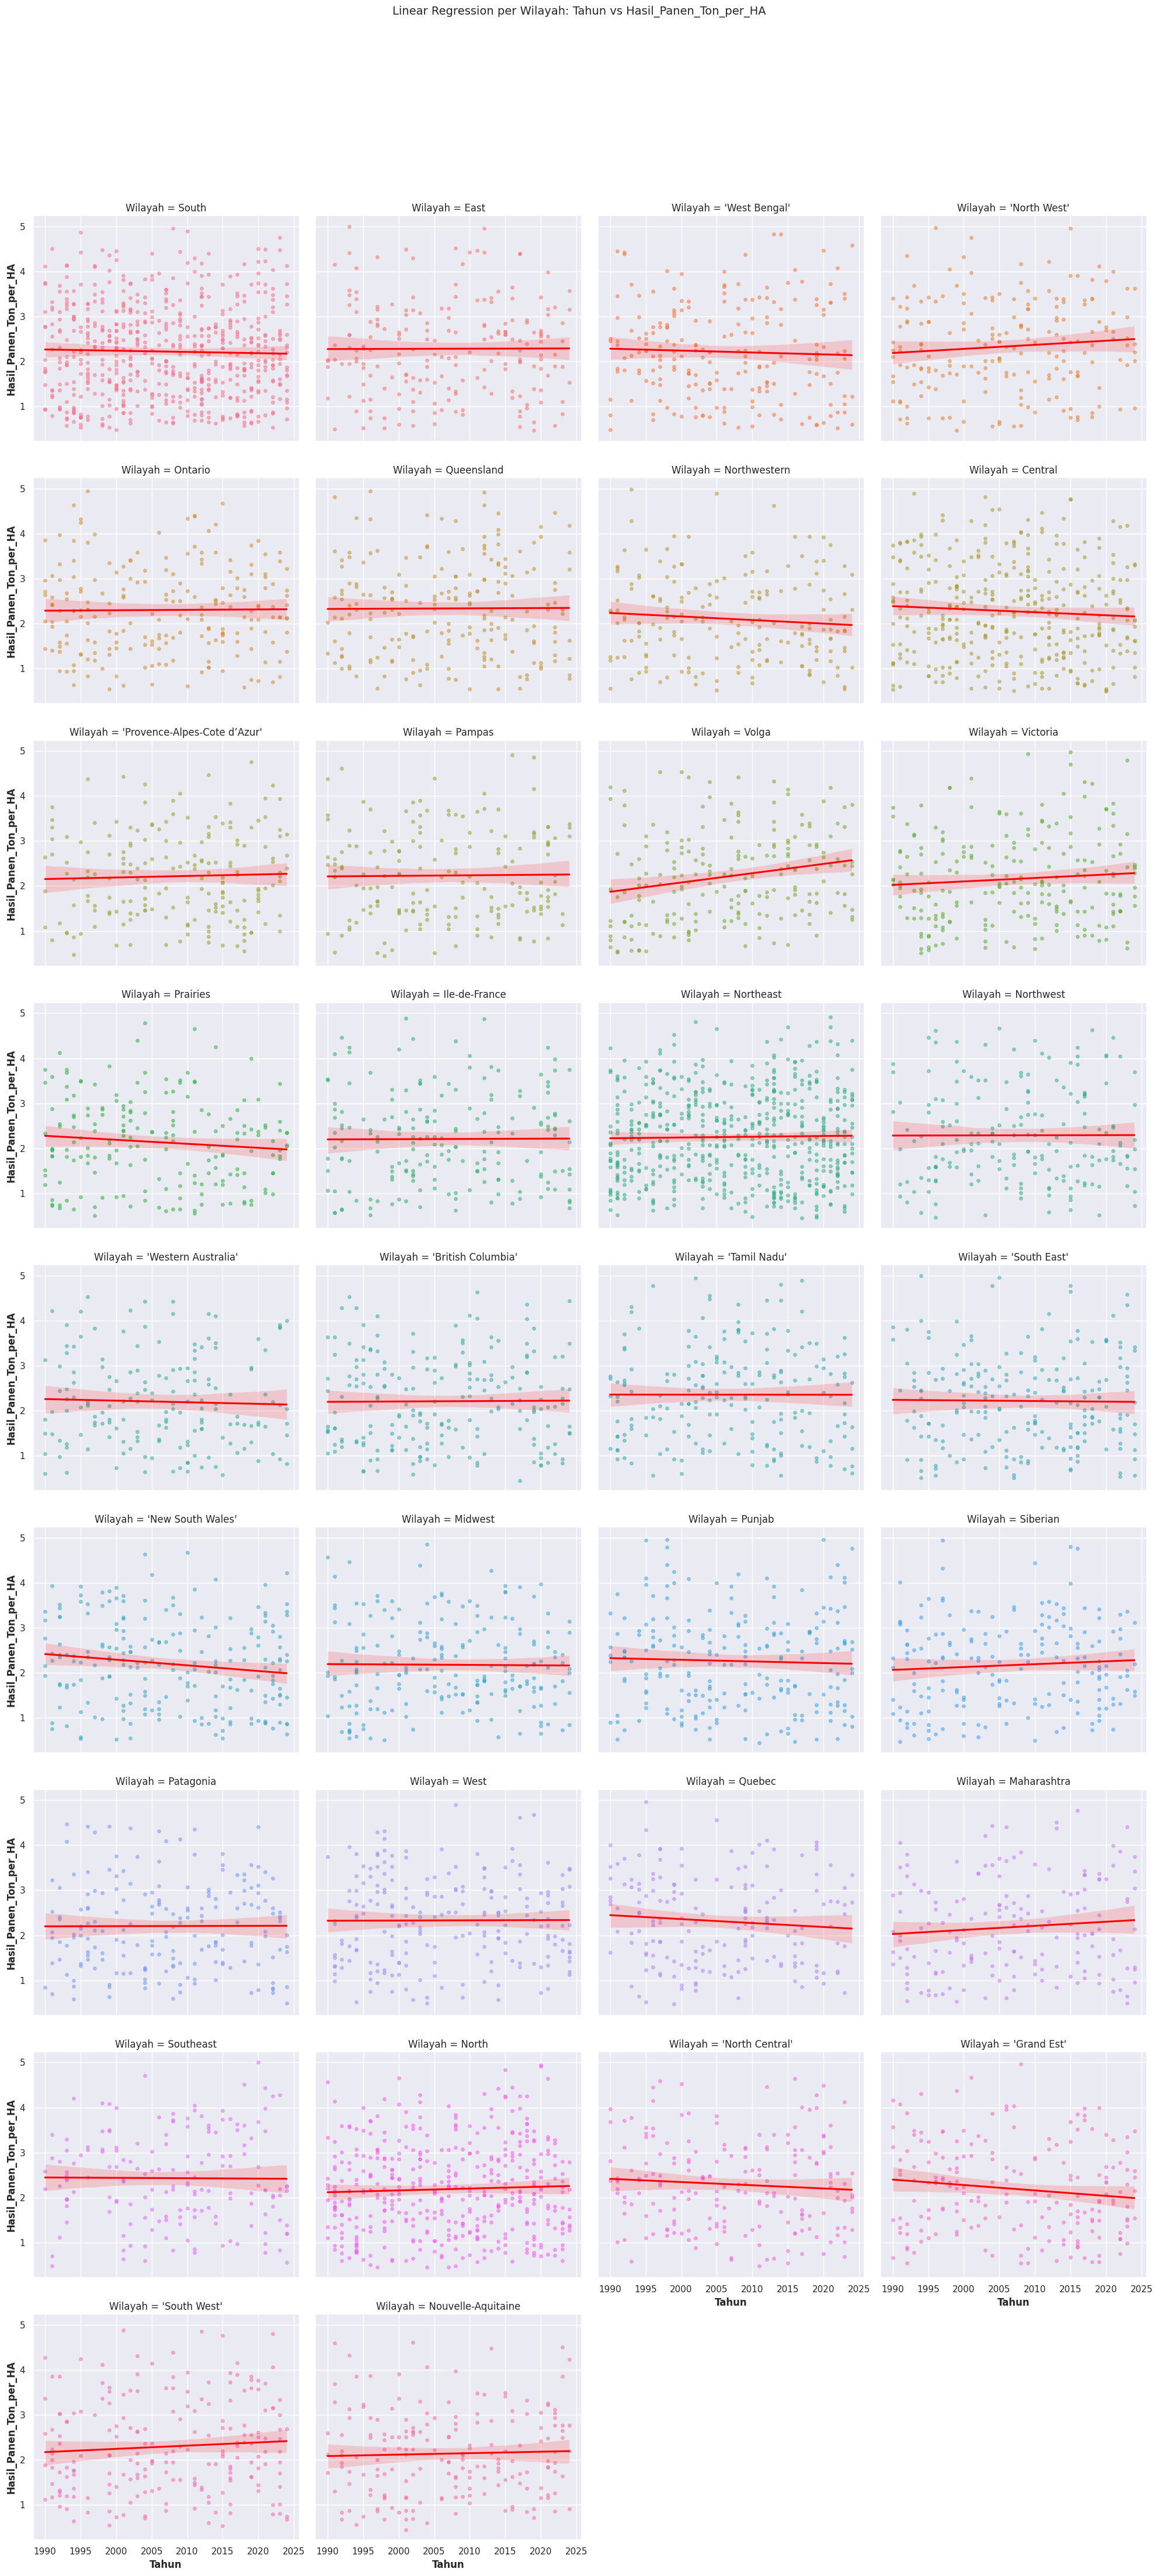

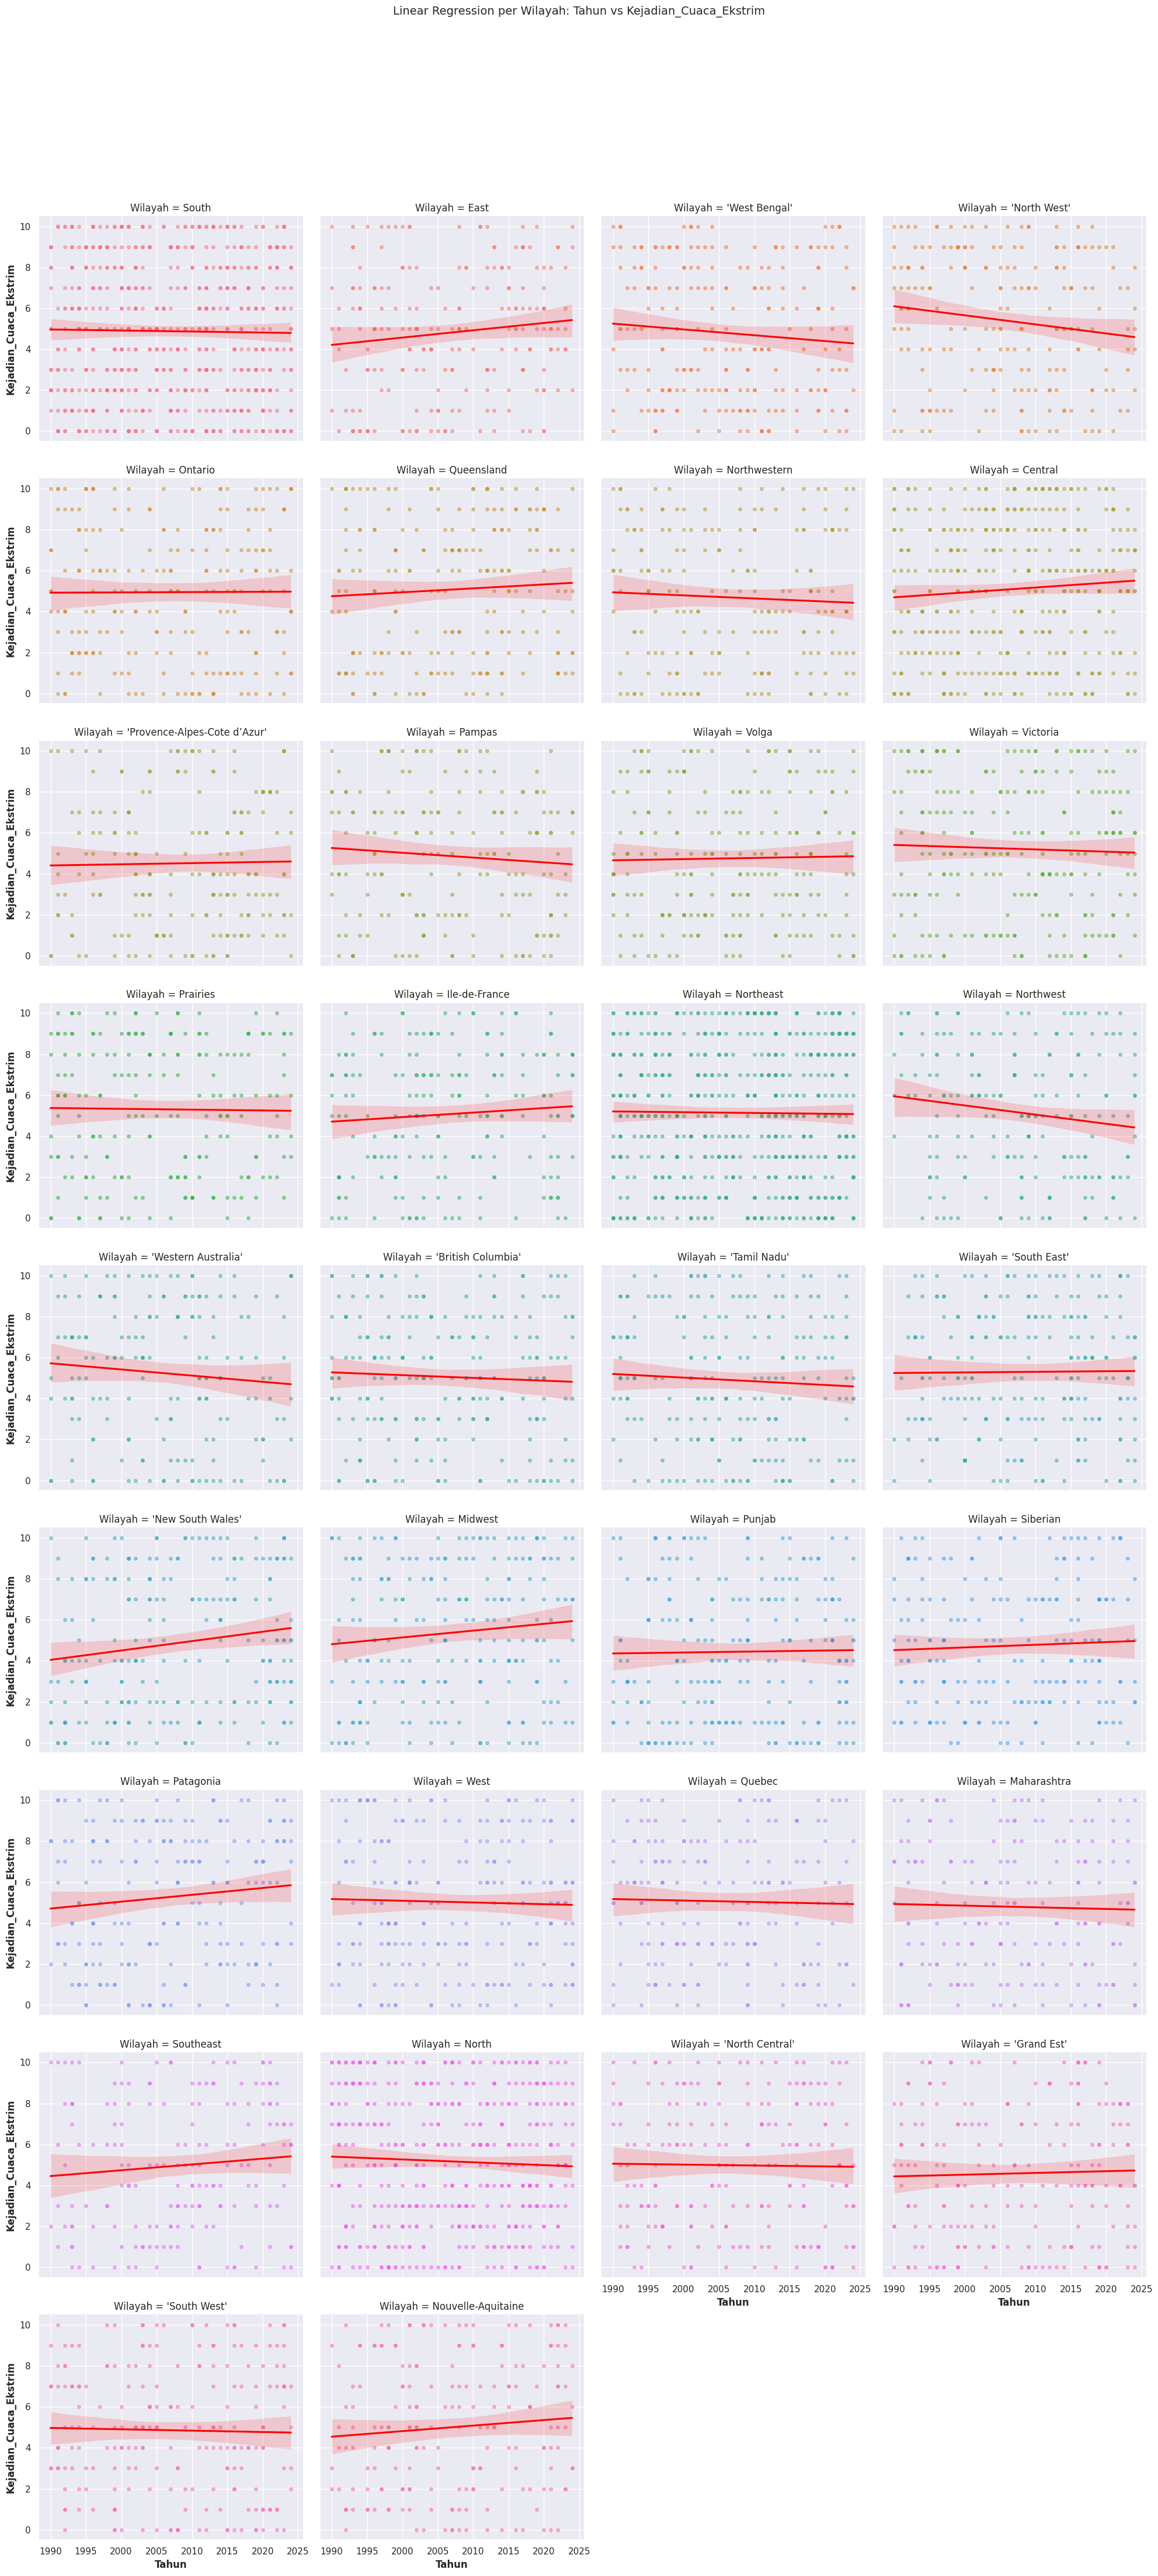

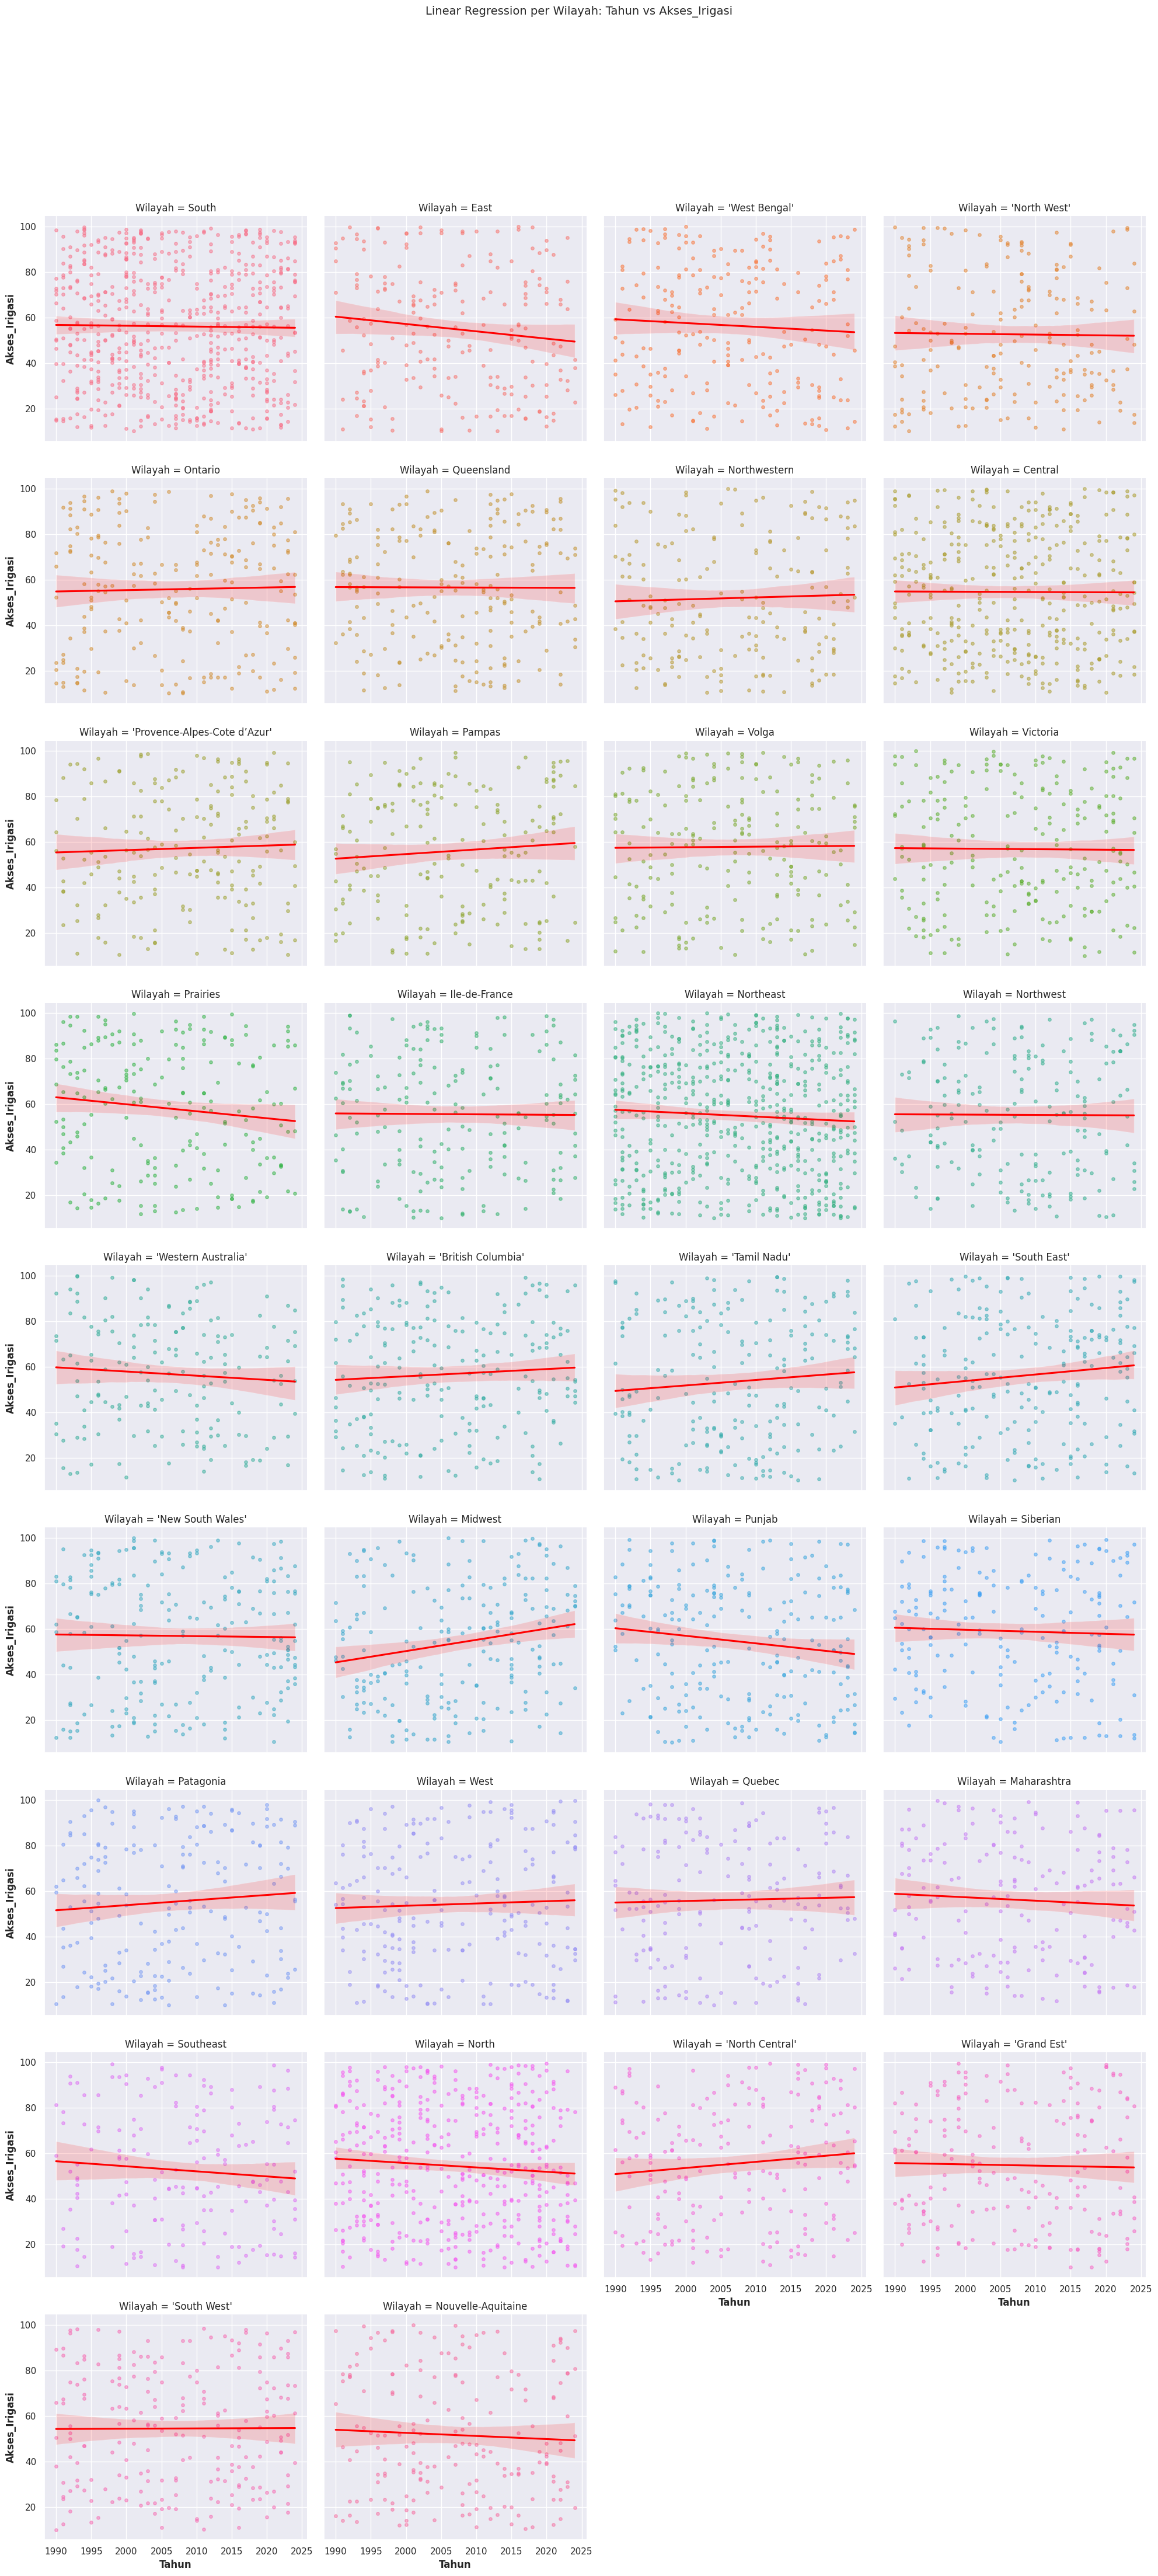

In [6]:
numeric_cols = df.select_dtypes(include=[np.number]).columns.drop('ID')
numeric_df = df[numeric_cols]

pairs = list(combinations(numeric_cols, 2))
print(f'Total pairs: {len(pairs)}')

def plot_feature_correlations(
    df: pd.DataFrame,
    group_col: str = 'Wilayah',
    max_plots: int = 10
) -> None:
    numeric_cols = df.select_dtypes(include=[np.number]).columns.drop('ID')
    pairs = list(combinations(numeric_cols, 2))

    for i, (x, y) in enumerate(pairs[:max_plots]):  # limit to first N pairs
        sns.lmplot(
            data=df,
            x=x,
            y=y,
            hue=group_col,
            col=group_col,
            col_wrap=4,
            scatter_kws={'alpha': 0.5, 's': 15},
            line_kws={'color': 'red'}
        )
        plt.subplots_adjust(top=0.9)
        plt.suptitle(f'Linear Regression per {group_col}: {x} vs {y}', fontsize=14)
        plt.show()

plot_feature_correlations(df, group_col='Wilayah', max_plots=5)

### 2.1.4 Temporal Dependency

Untuk mengetahui keterkaitan antara data yang ada dengan data-data yang ada di masa lampau. Teknik yang digunakan adalah **Autocorrelation Function (ACF)** dan juga **Partial Autocorrelation Function (PACF)**.

#### Global Trend Over Years

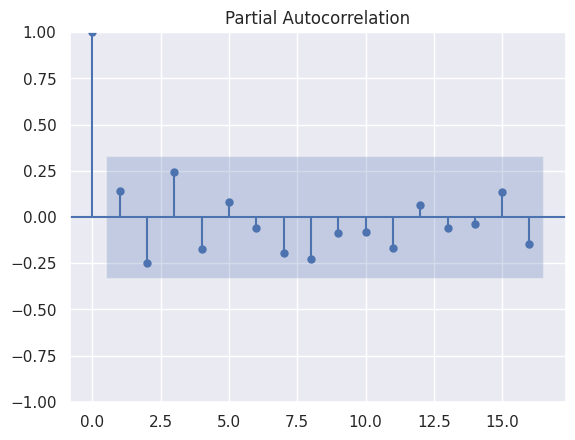

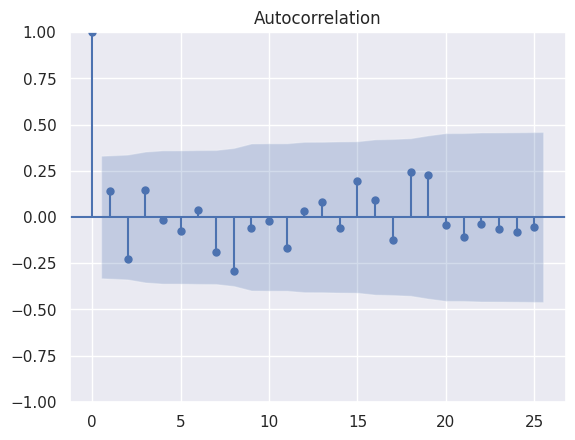

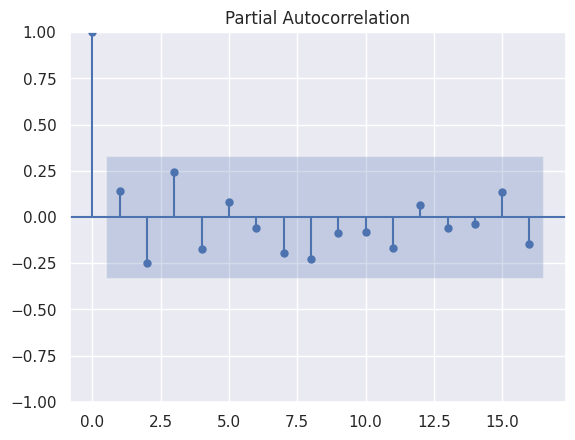

In [7]:
df_yearly = df.groupby("Tahun", as_index=False)["Suhu_Rata_Rata_C"].mean()

series = df_yearly["Suhu_Rata_Rata_C"]

plot_acf(series, lags=25)
plot_pacf(series, lags=16, method='ywm')

Hasil yang didapat adalah nilai berada di antara $+0.25$ hingga $-0.25$. Ini menunjukkan data tidak terlalu bergantung pada data-data pada masa lampau jika dilihat dari pola data secara global.

#### Analisis Satu Negara + Tahun

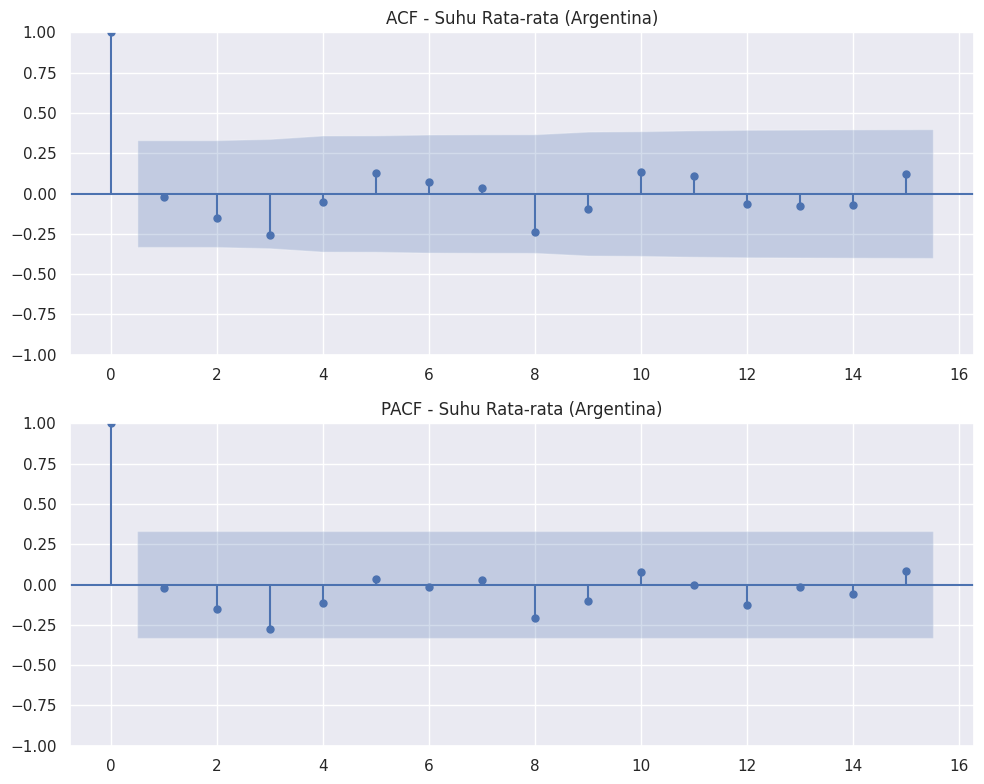

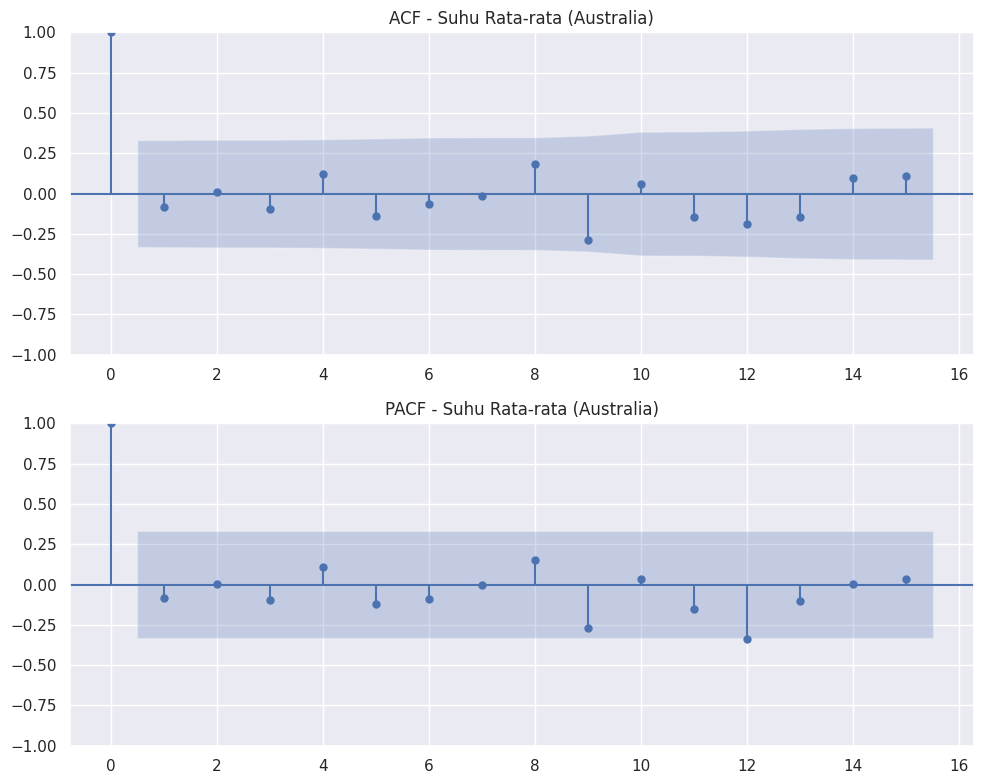

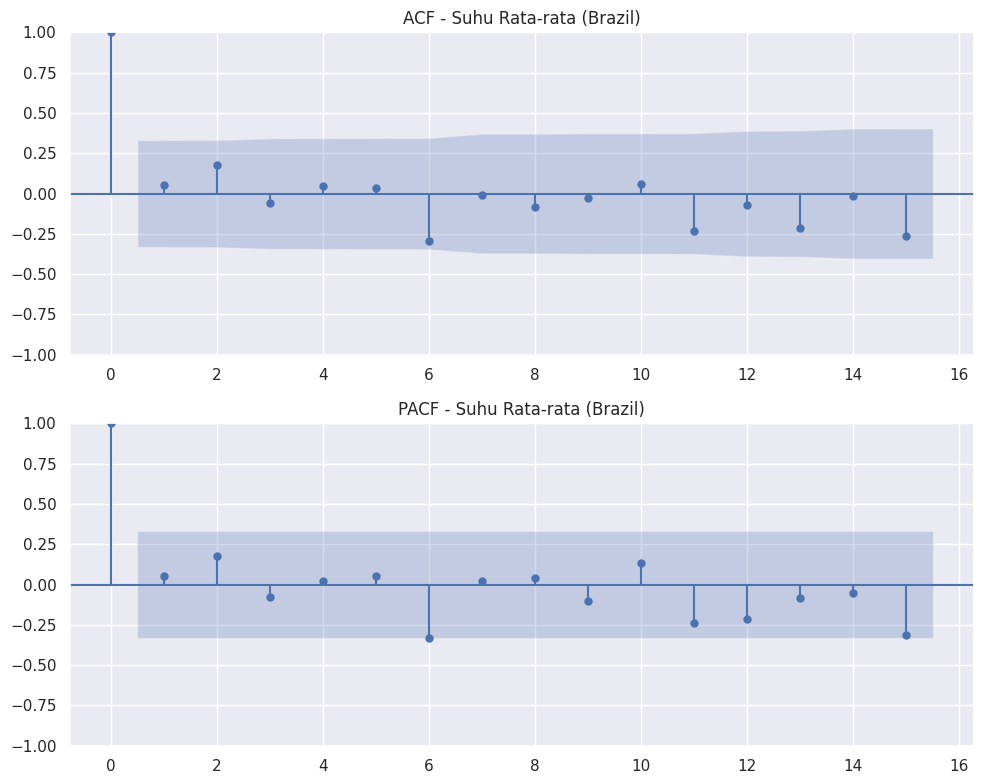

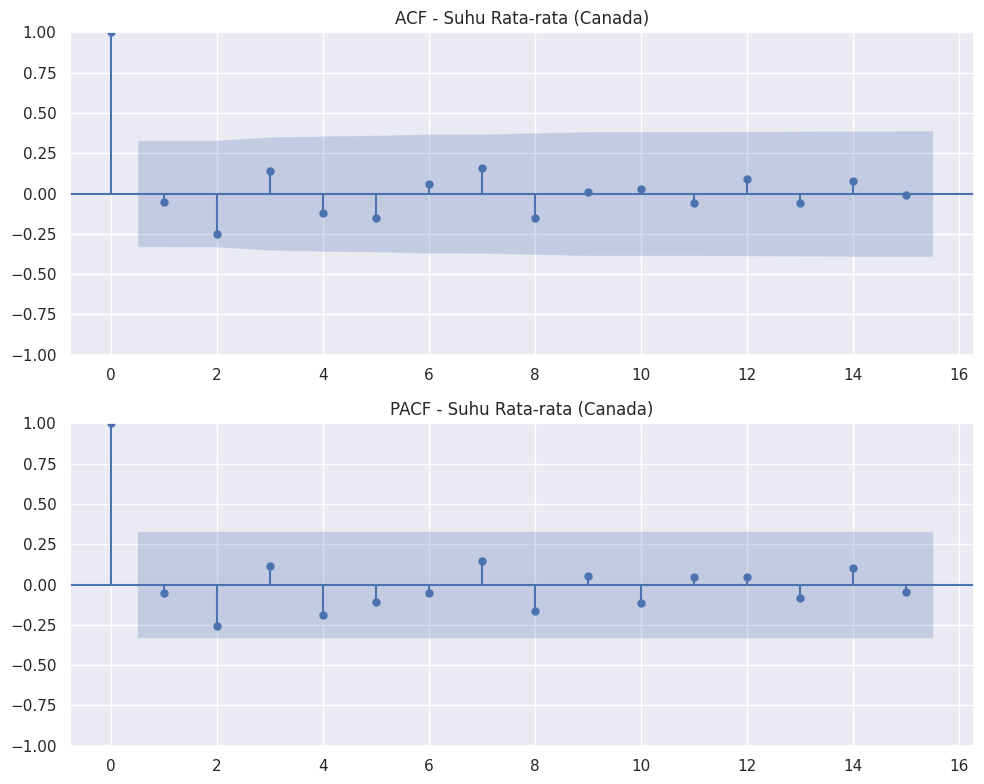

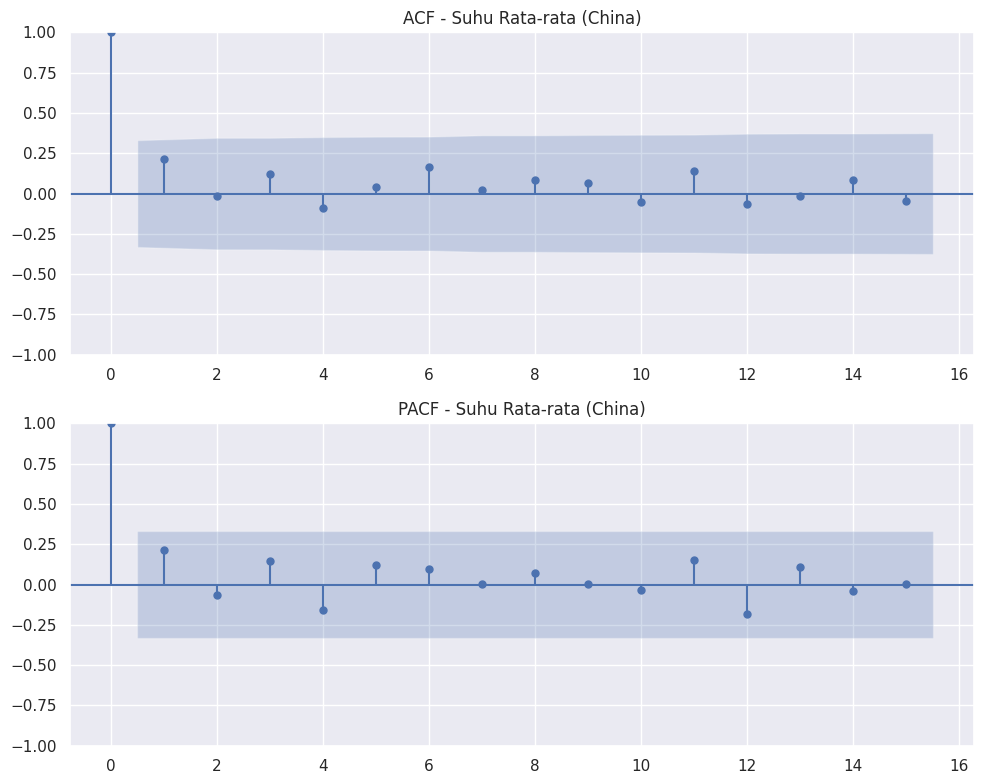

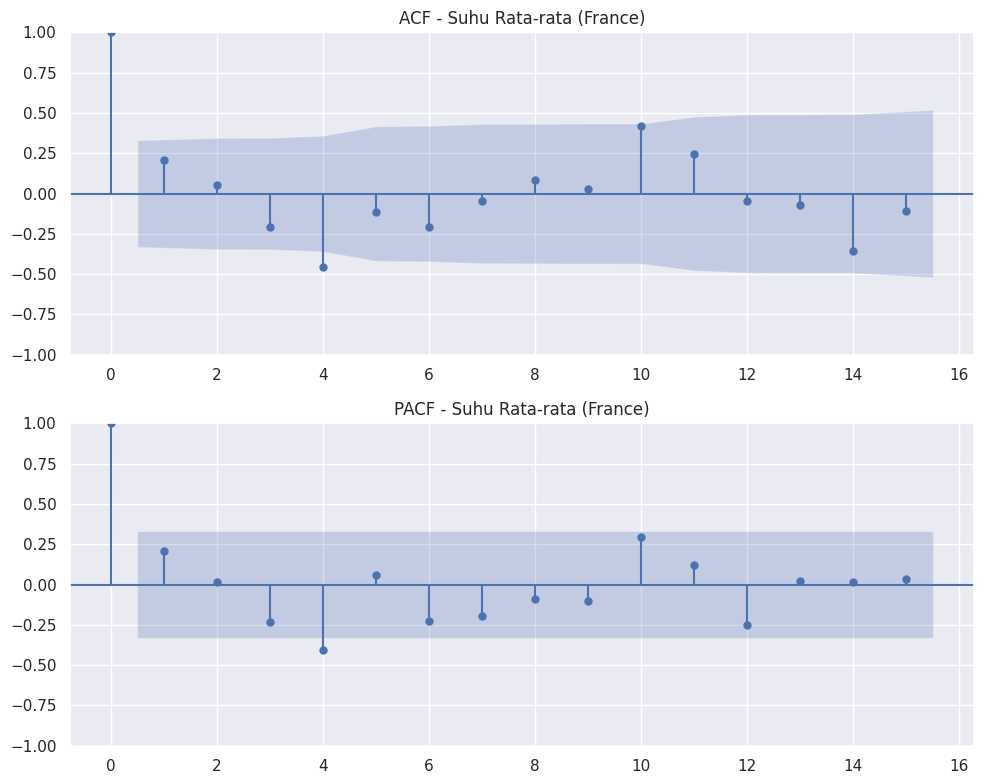

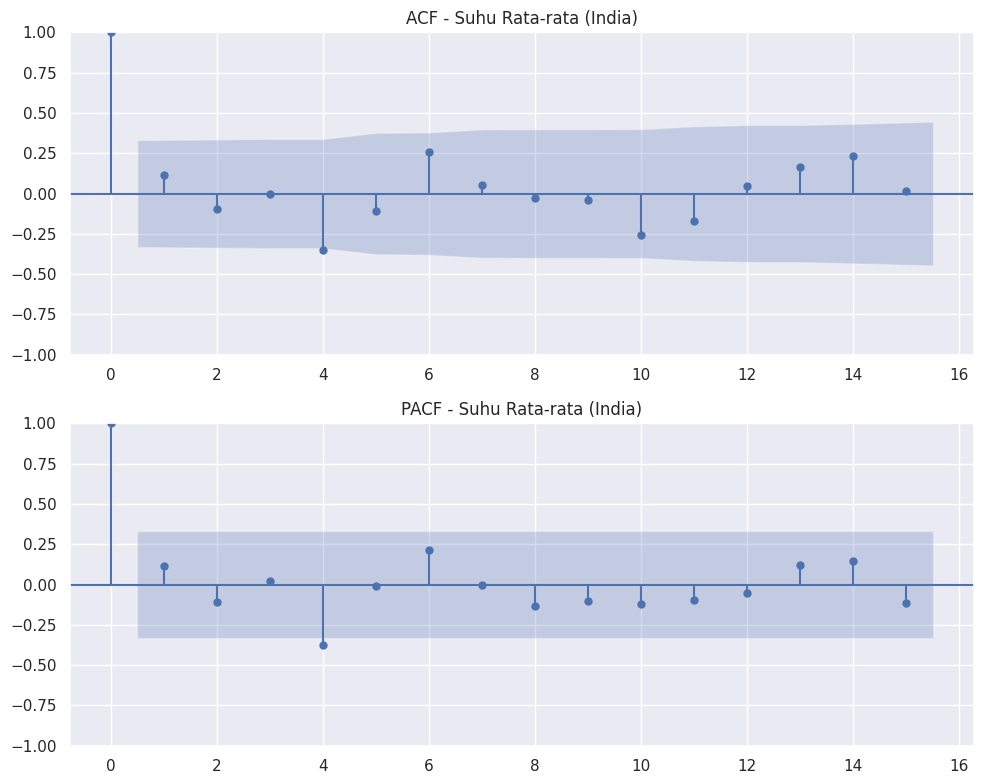

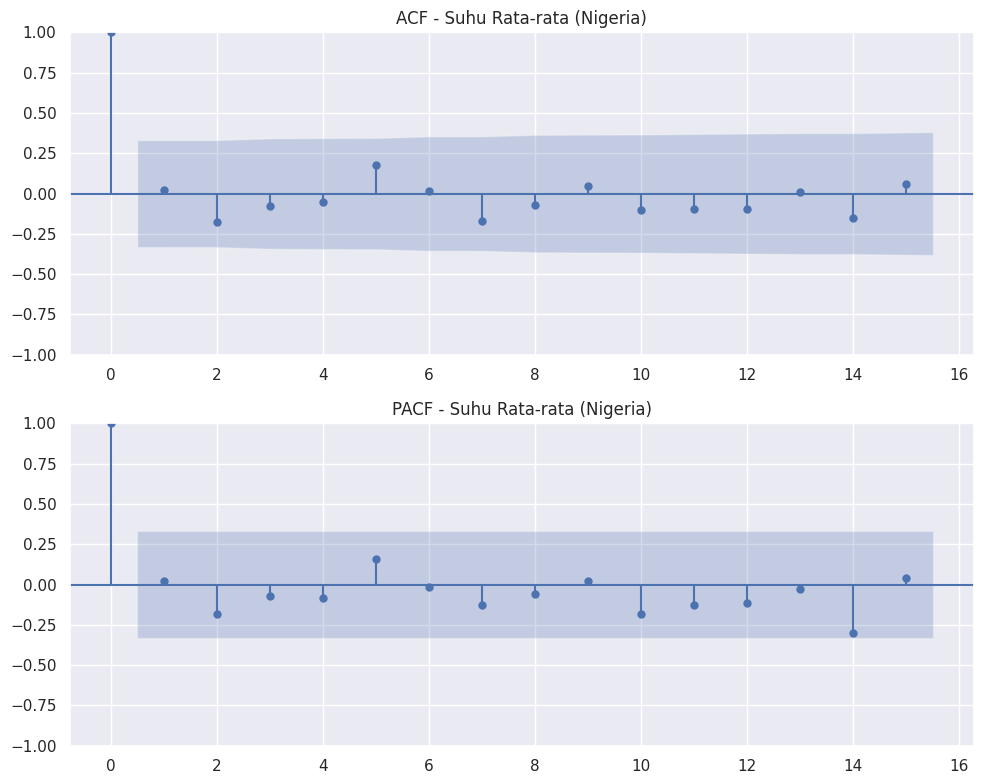

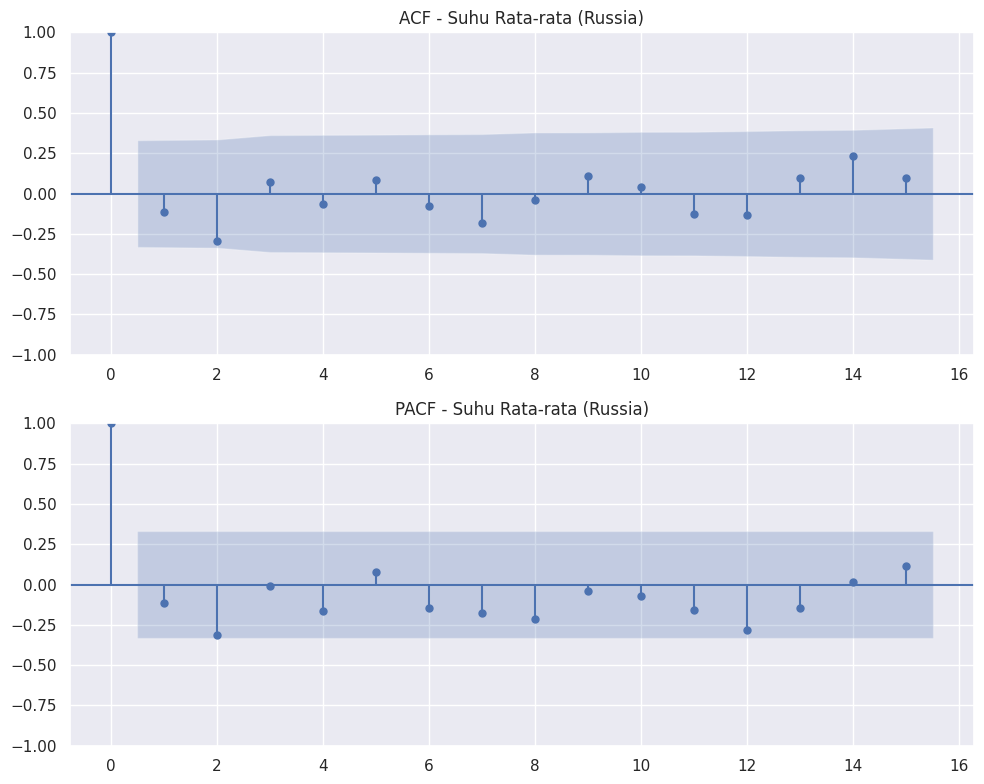

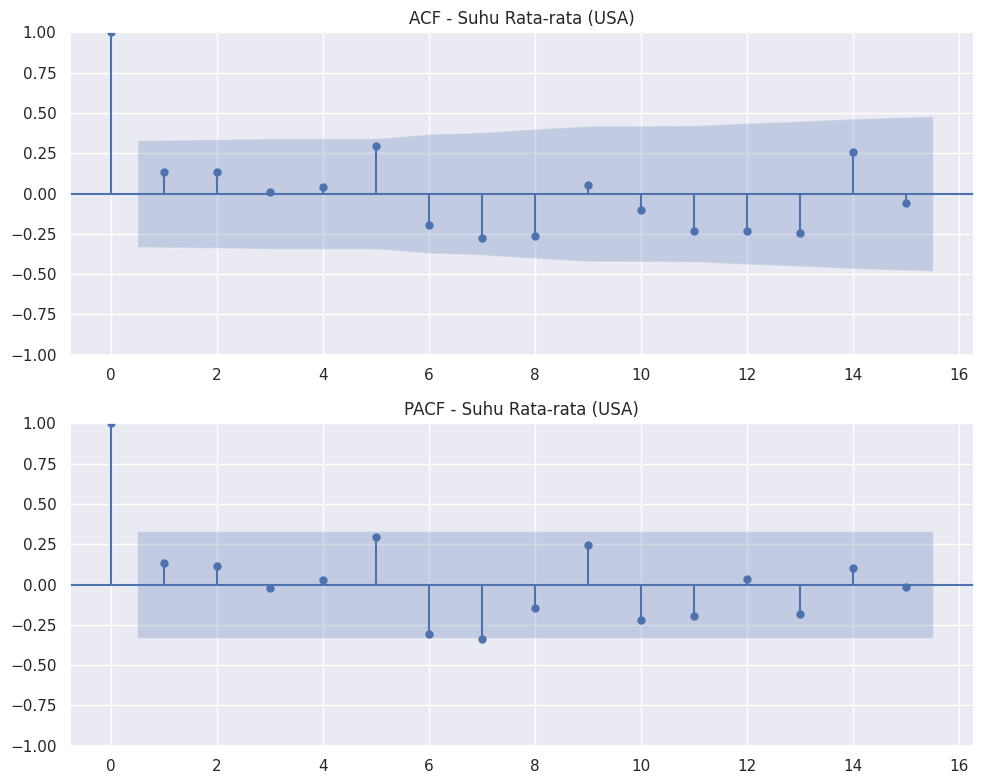

In [8]:
df_country_year = (
    df.groupby(["Nama_Negara", "Tahun"], as_index=False)["Suhu_Rata_Rata_C"].mean()
)

countries = df_country_year["Nama_Negara"].unique()

for country in countries:
    df_sub = df_country_year[df_country_year["Nama_Negara"] == country].sort_values("Tahun")
    series = df_sub["Suhu_Rata_Rata_C"]

    fig, ax = plt.subplots(2, 1, figsize=(10, 8))
    plot_acf(series, lags=15, ax=ax[0], alpha=0.05)
    ax[0].set_title(f"ACF - Suhu Rata-rata ({country})")

    plot_pacf(series, lags=15, ax=ax[1], alpha=0.05, method='ywm')
    ax[1].set_title(f"PACF - Suhu Rata-rata ({country})")

    plt.tight_layout()
    plt.show()

#### Negara + Wilayah + Tahun

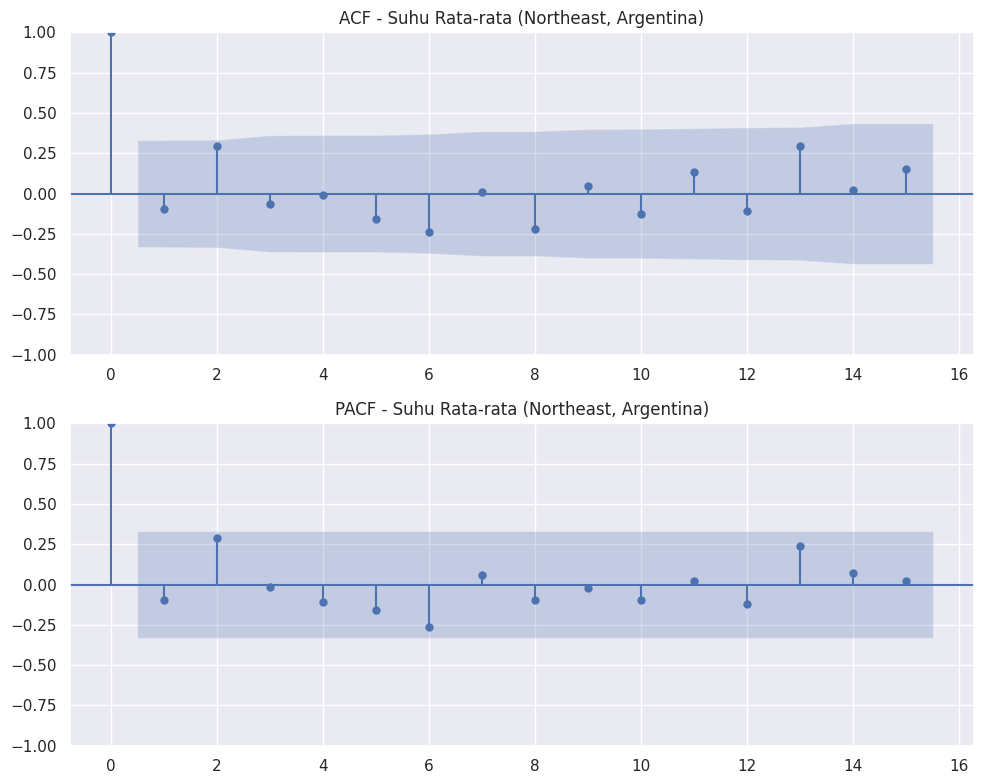

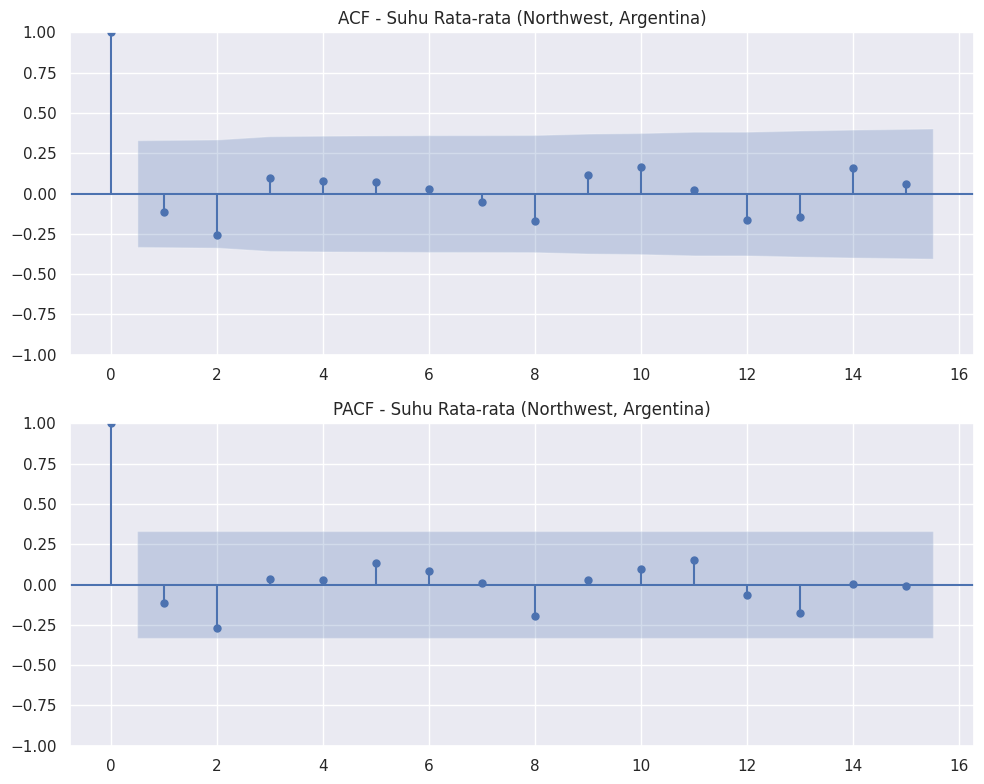

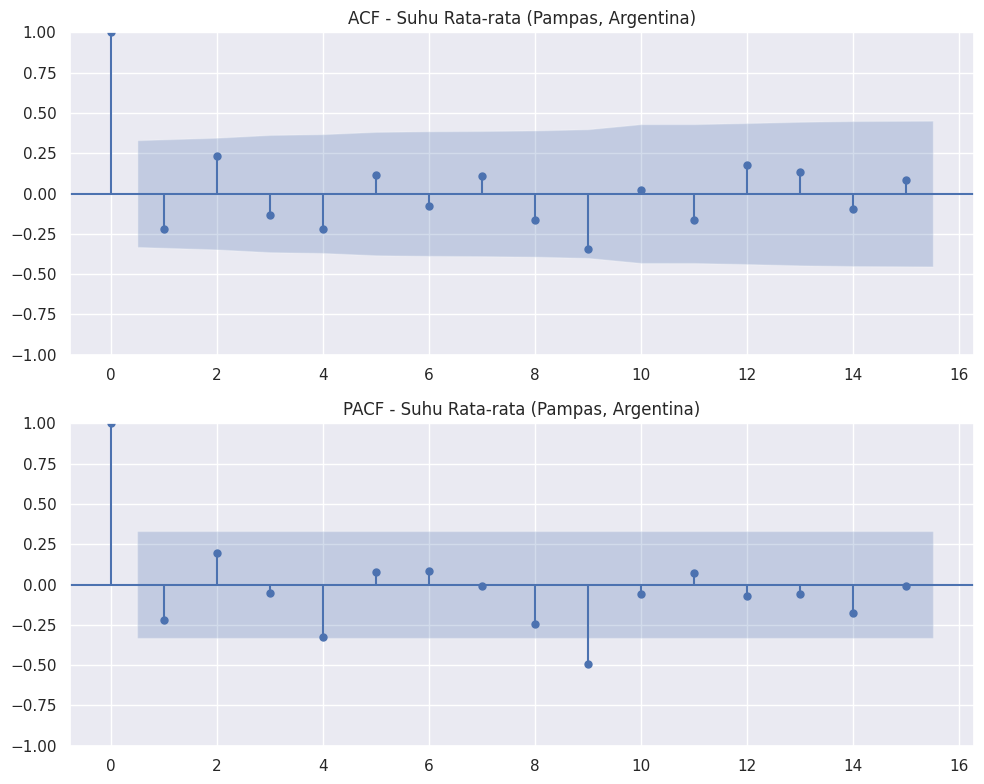

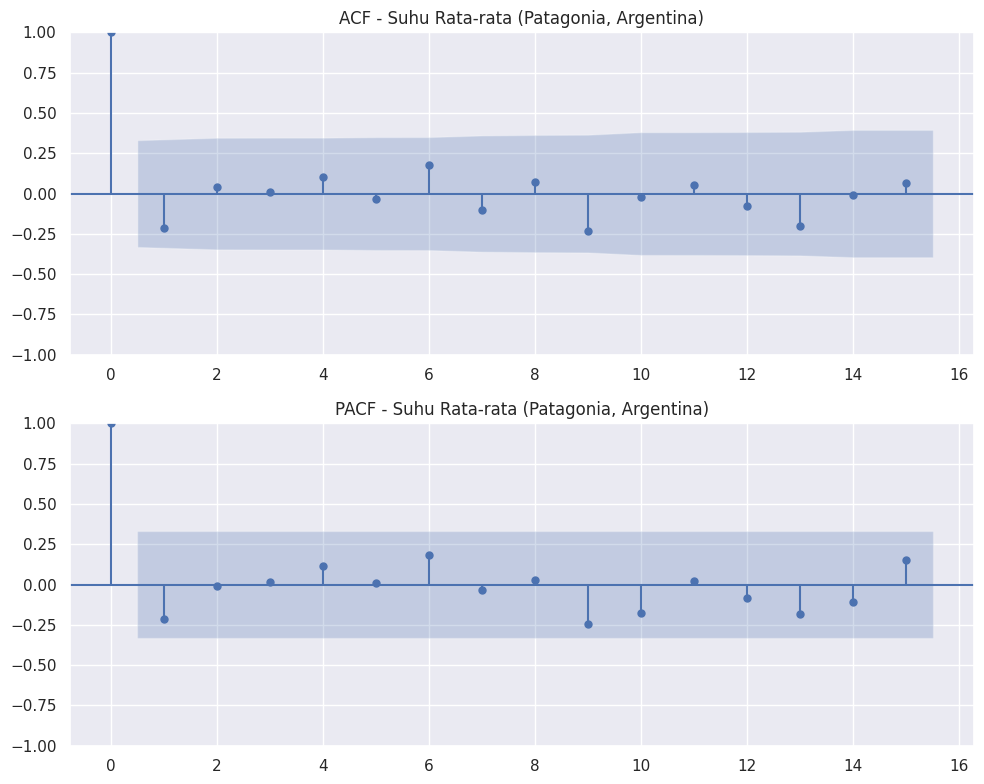

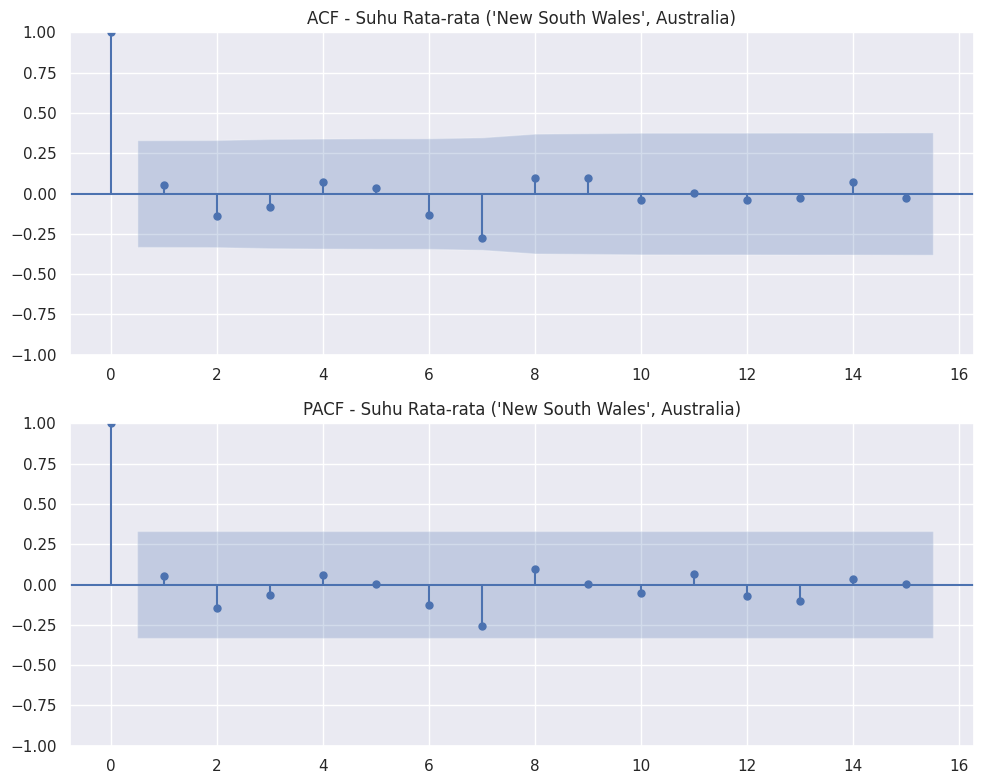

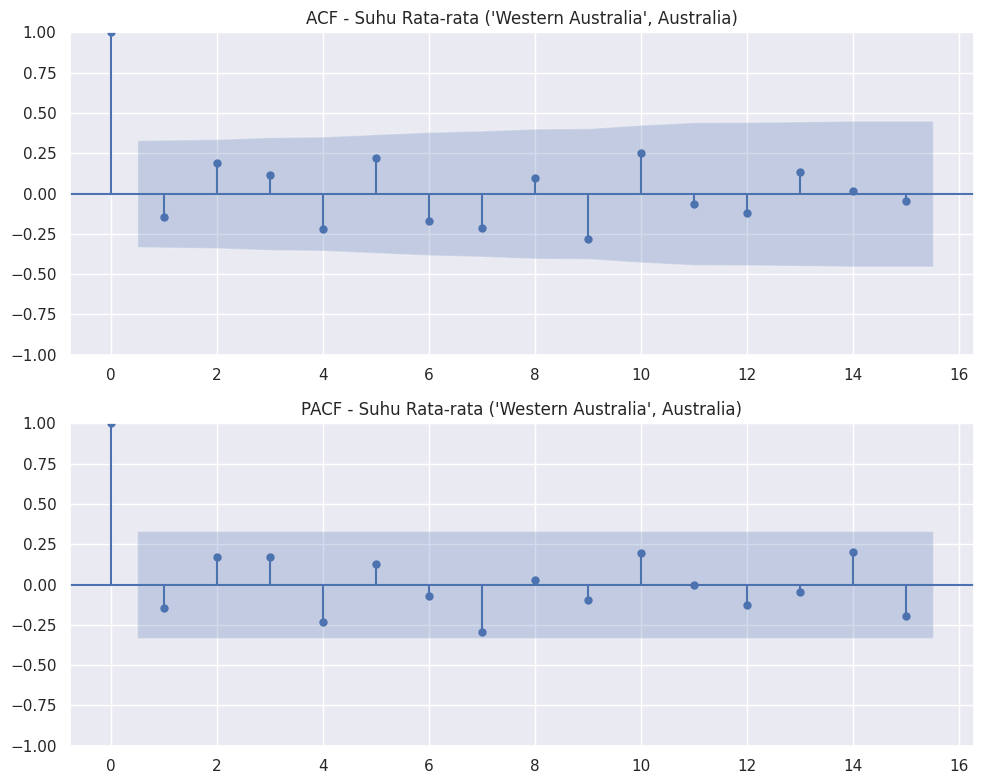

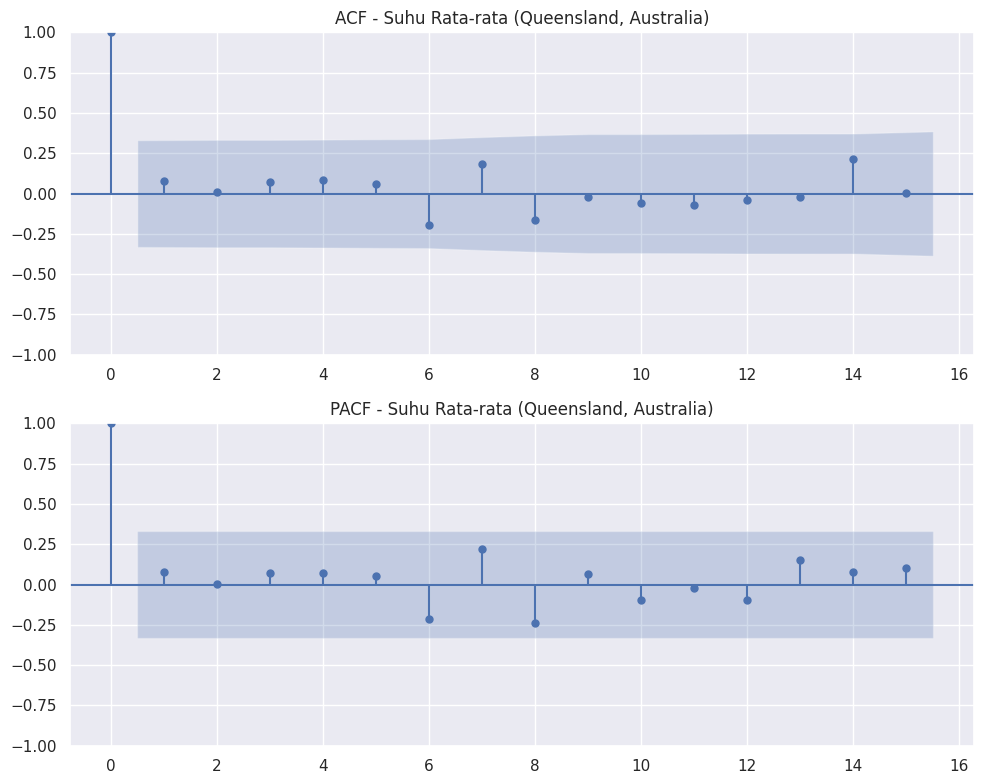

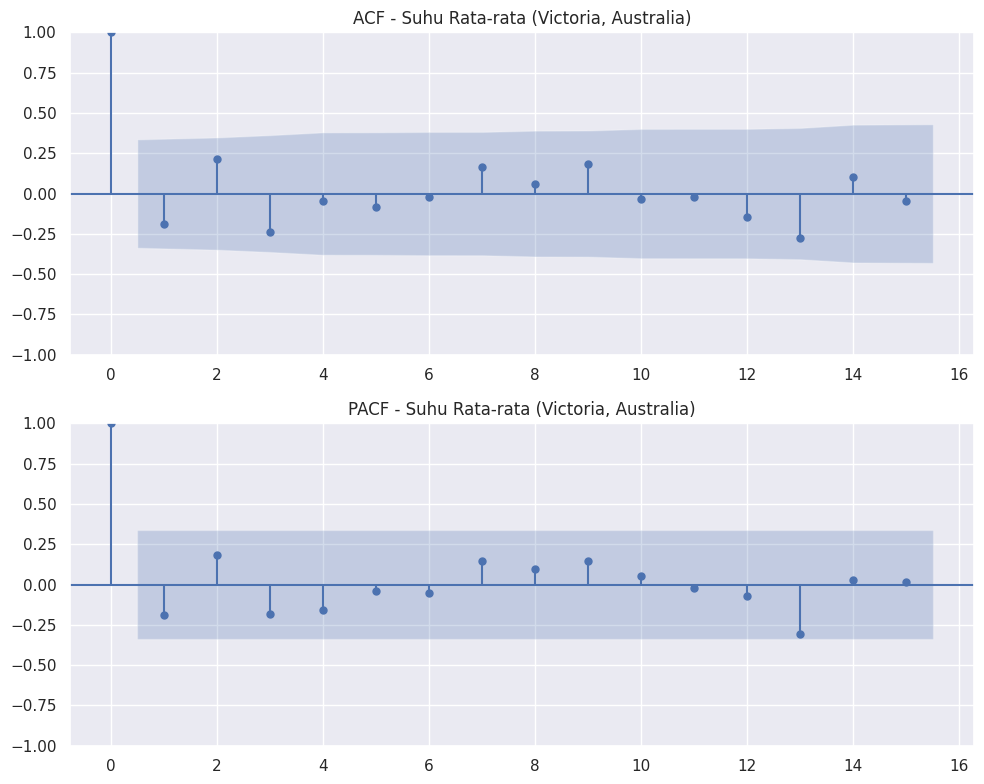

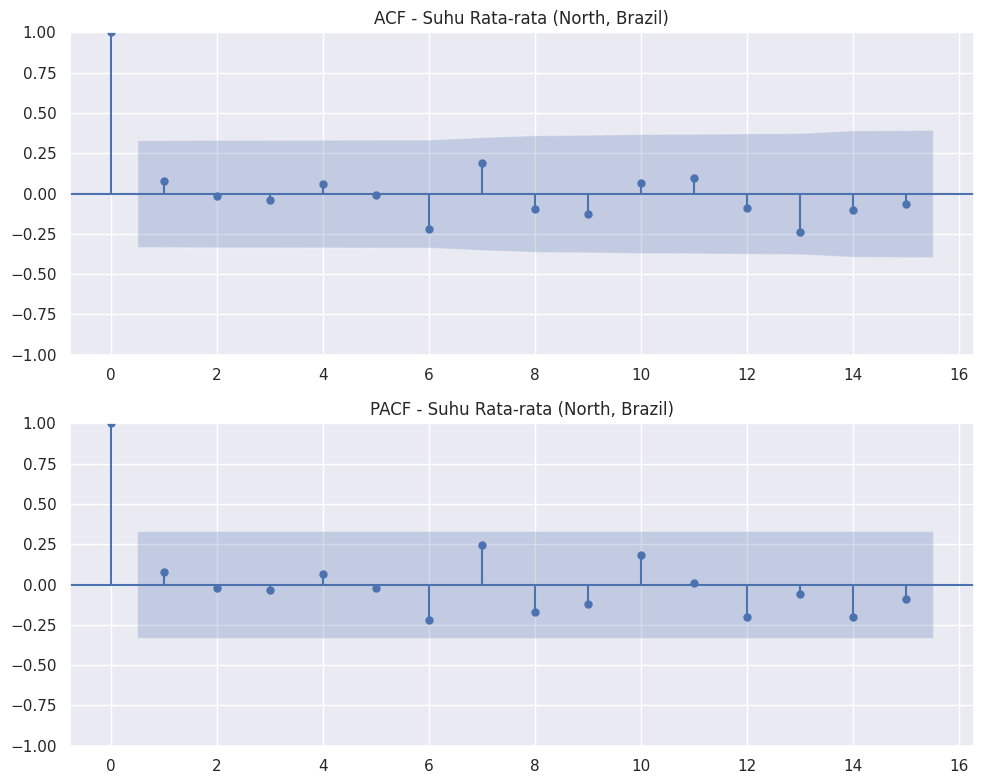

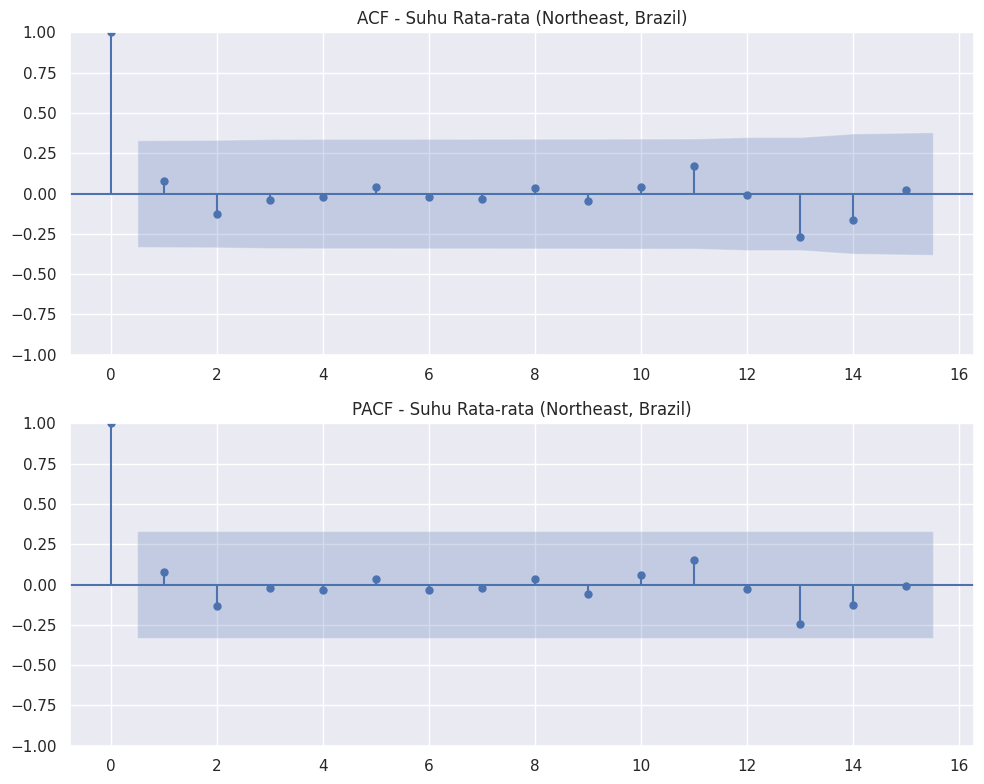

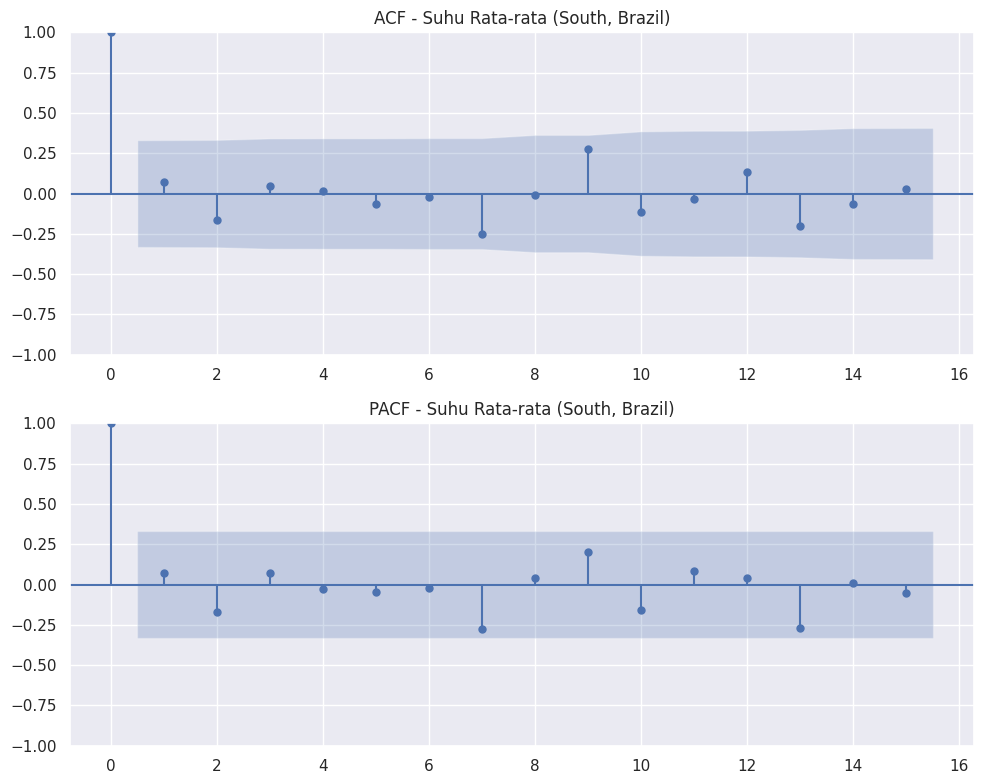

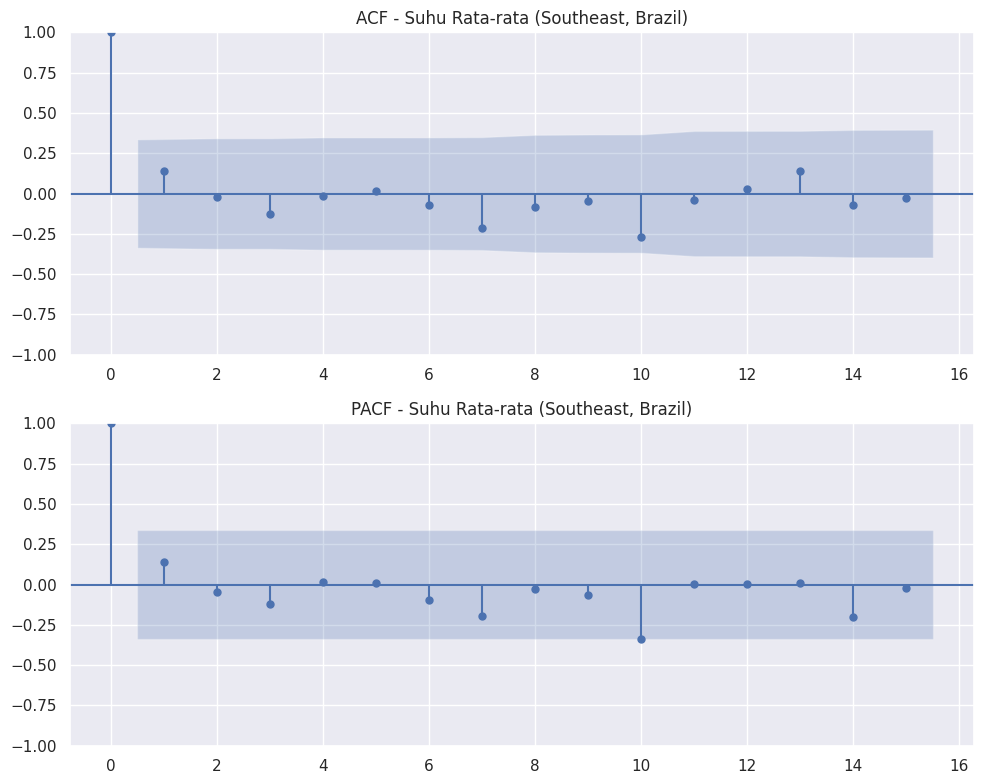

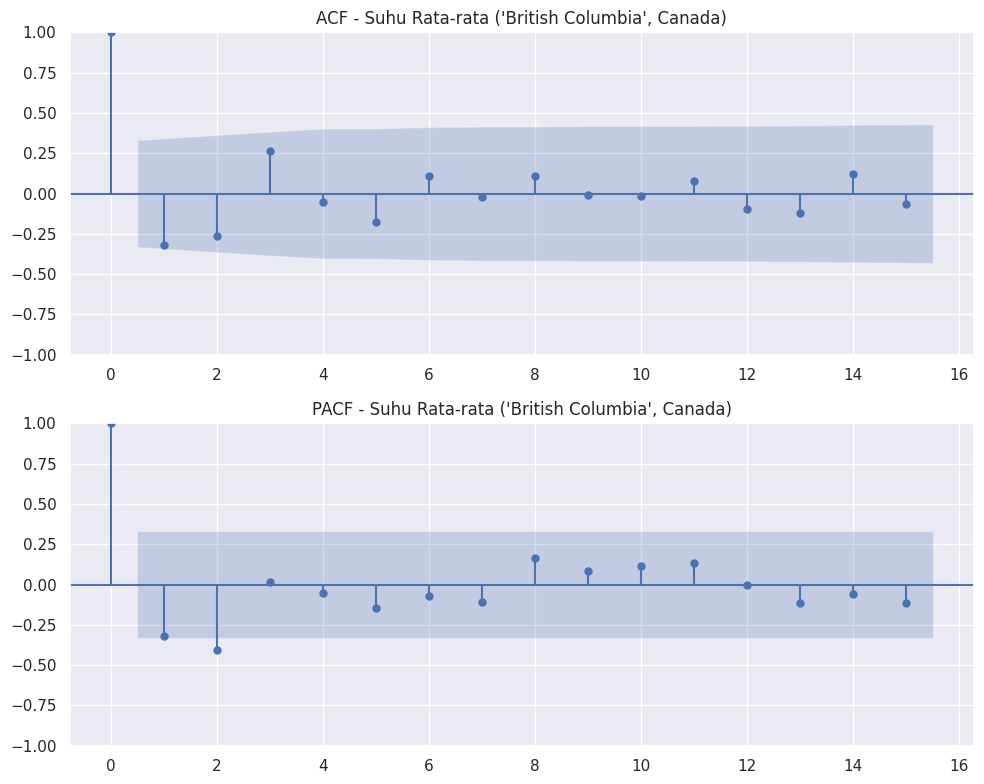

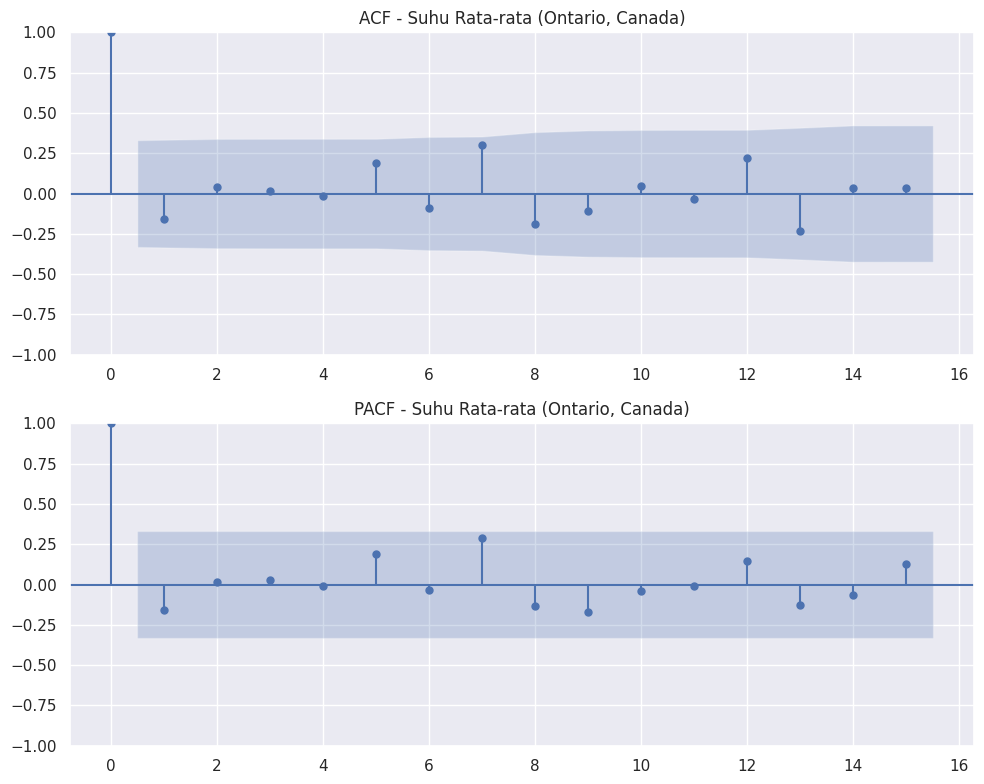

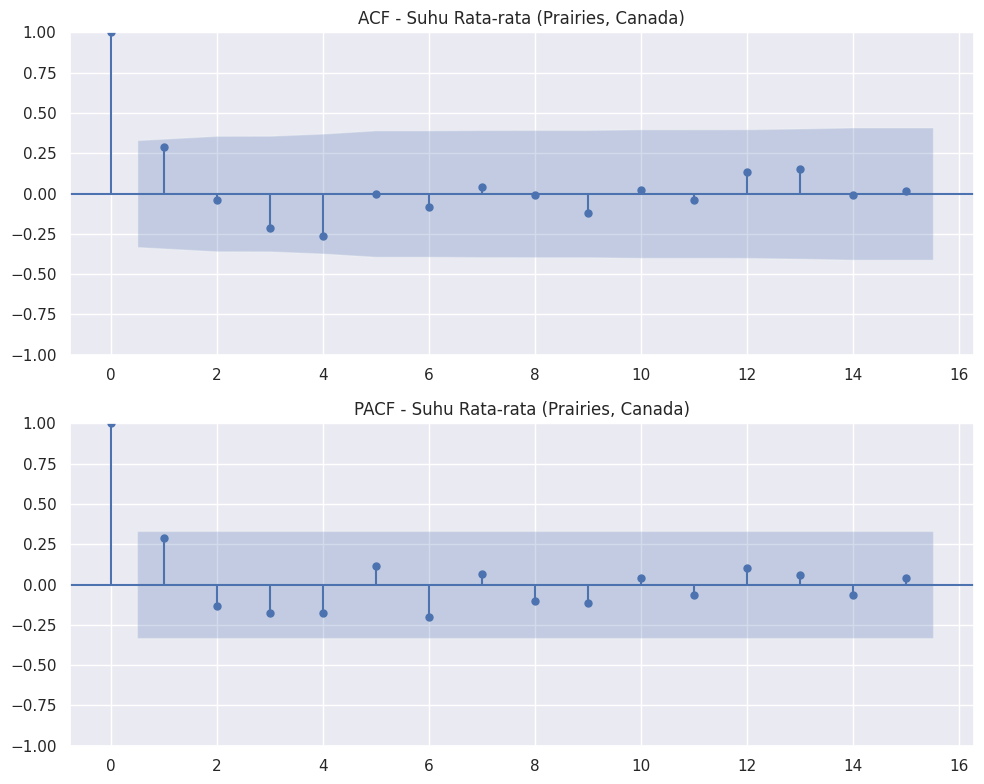

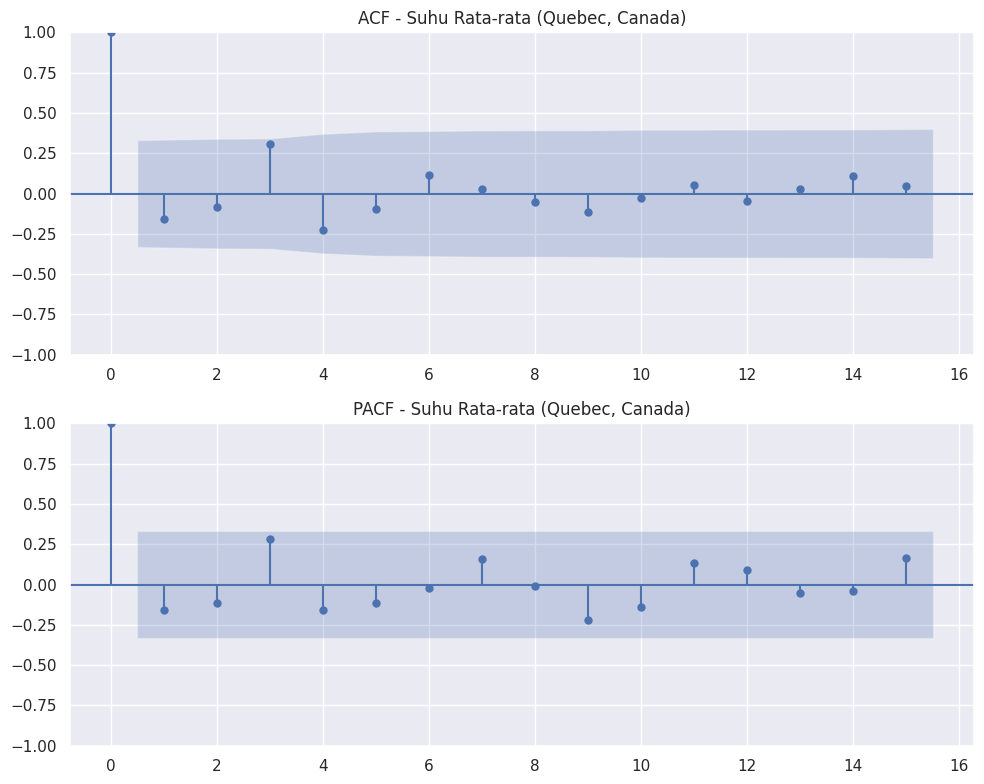

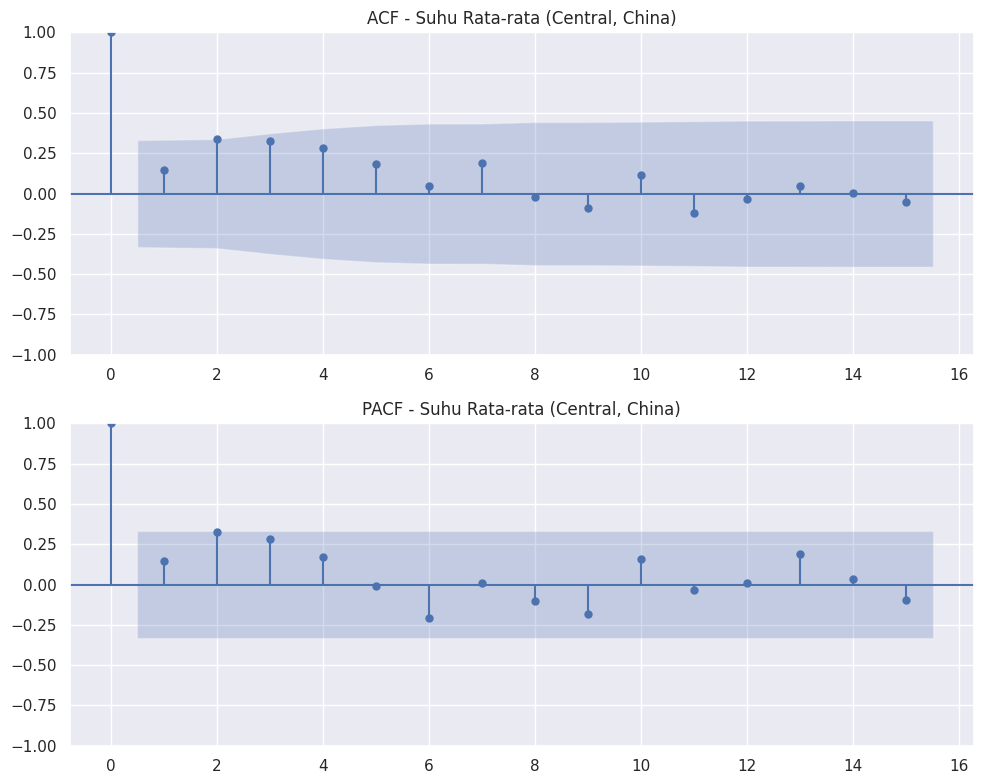

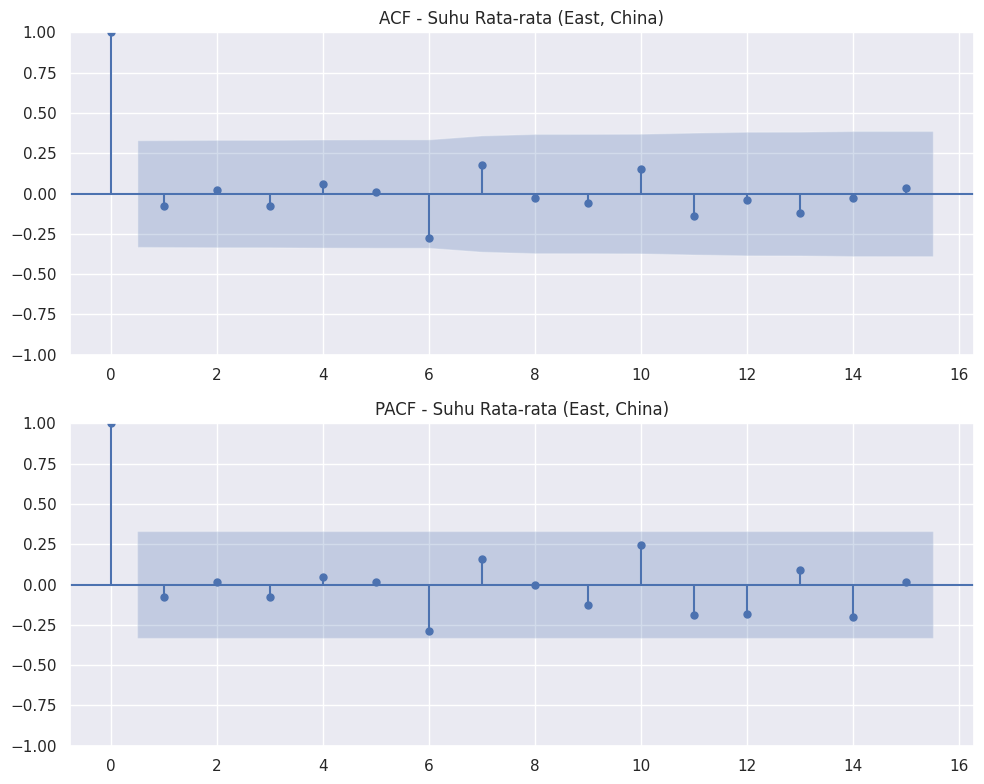

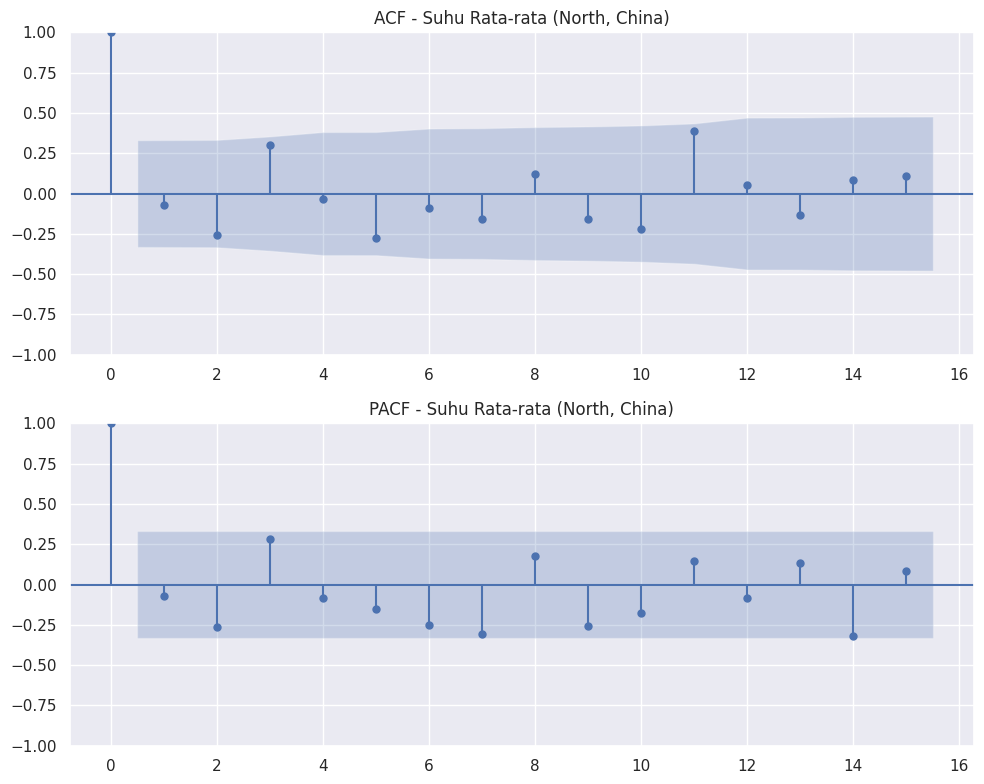

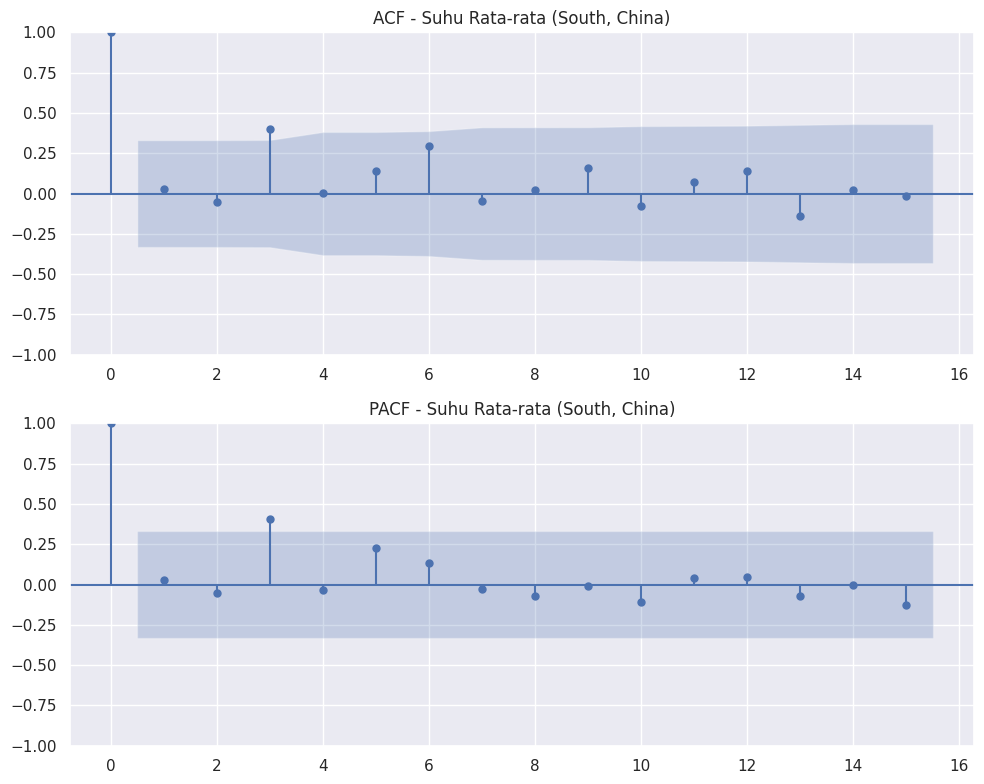

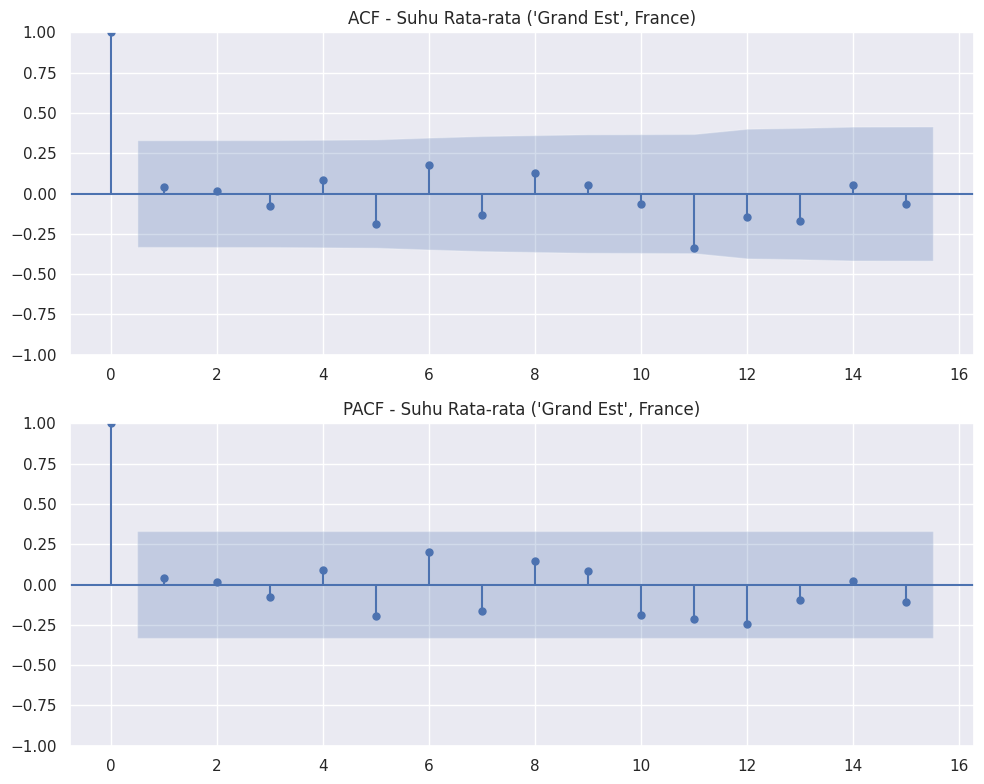

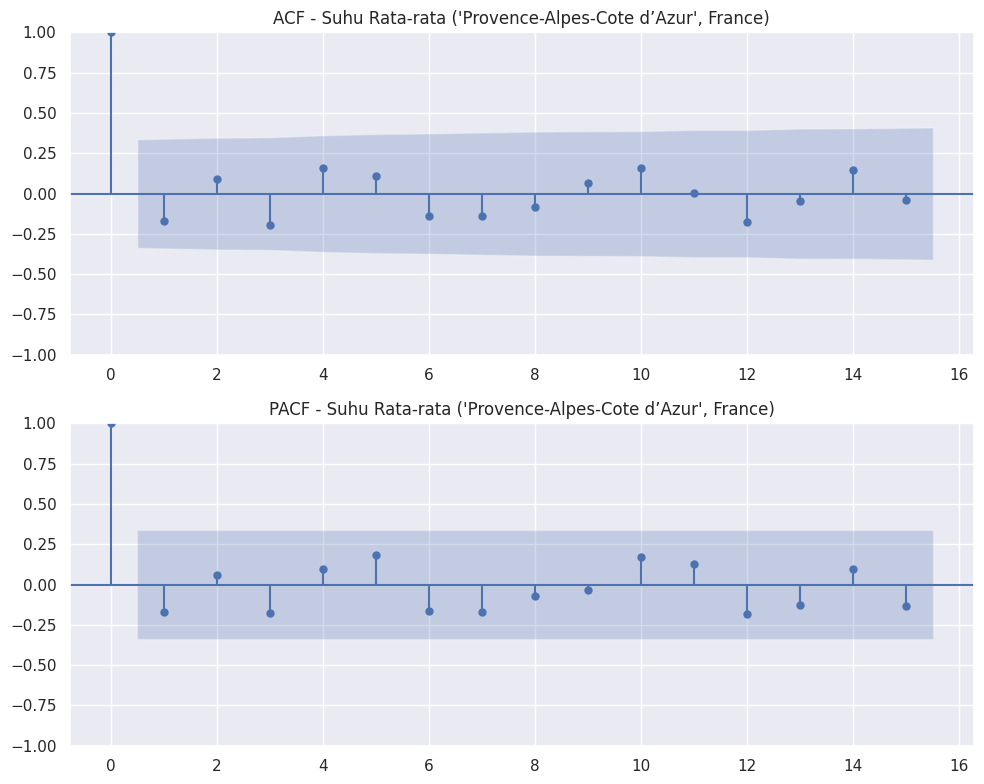

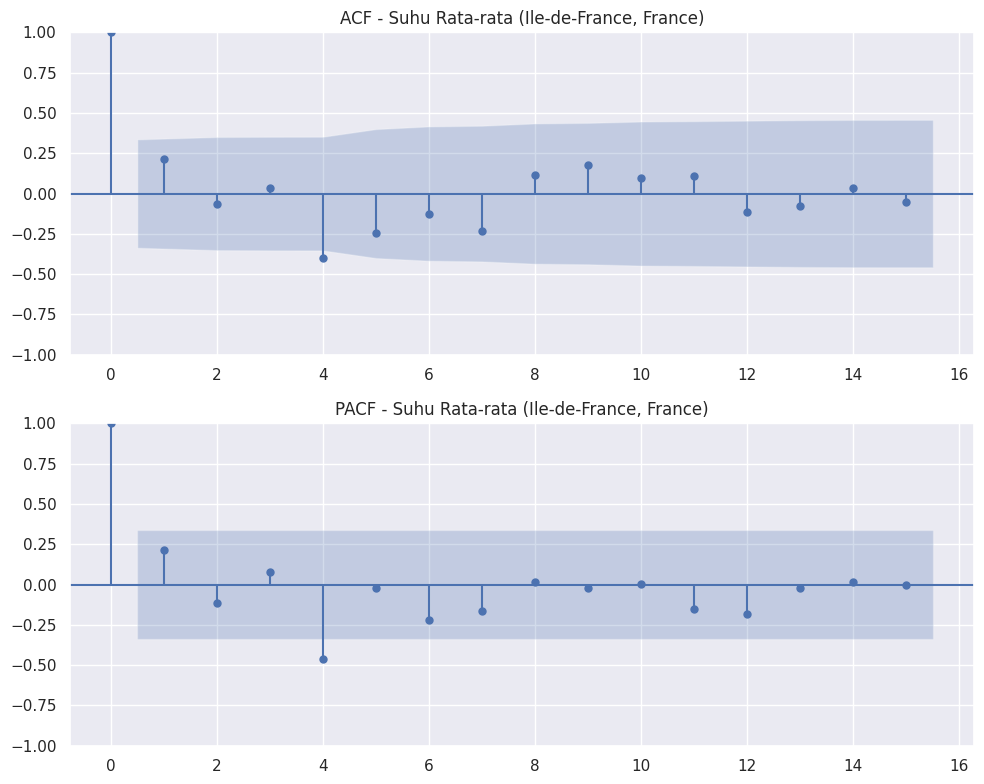

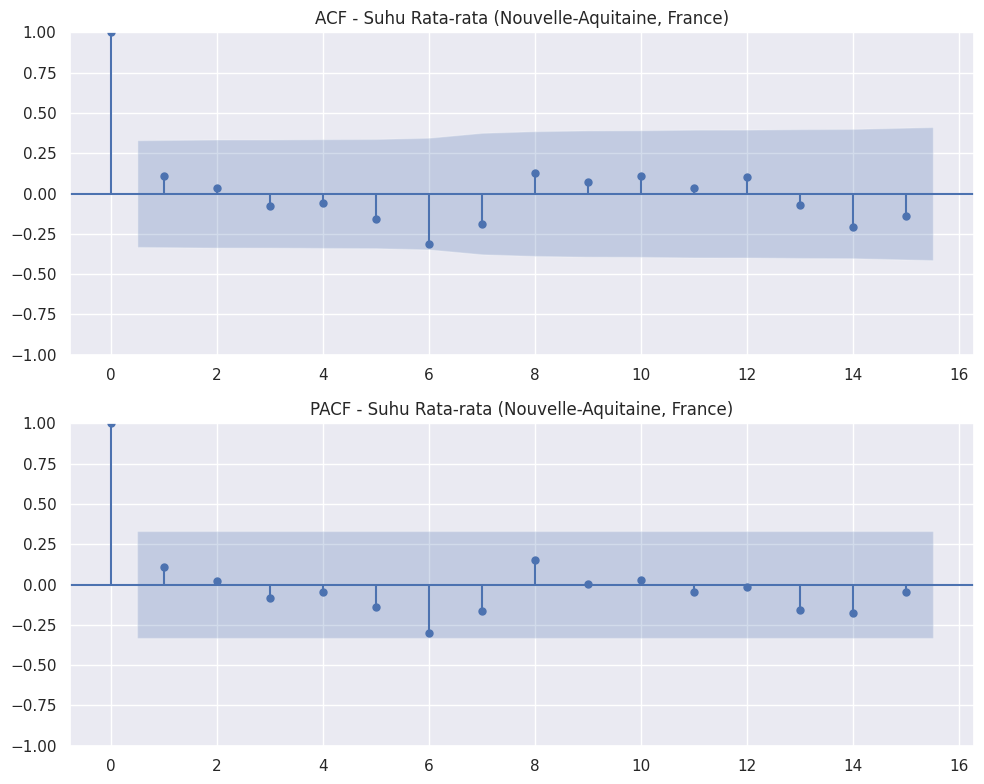

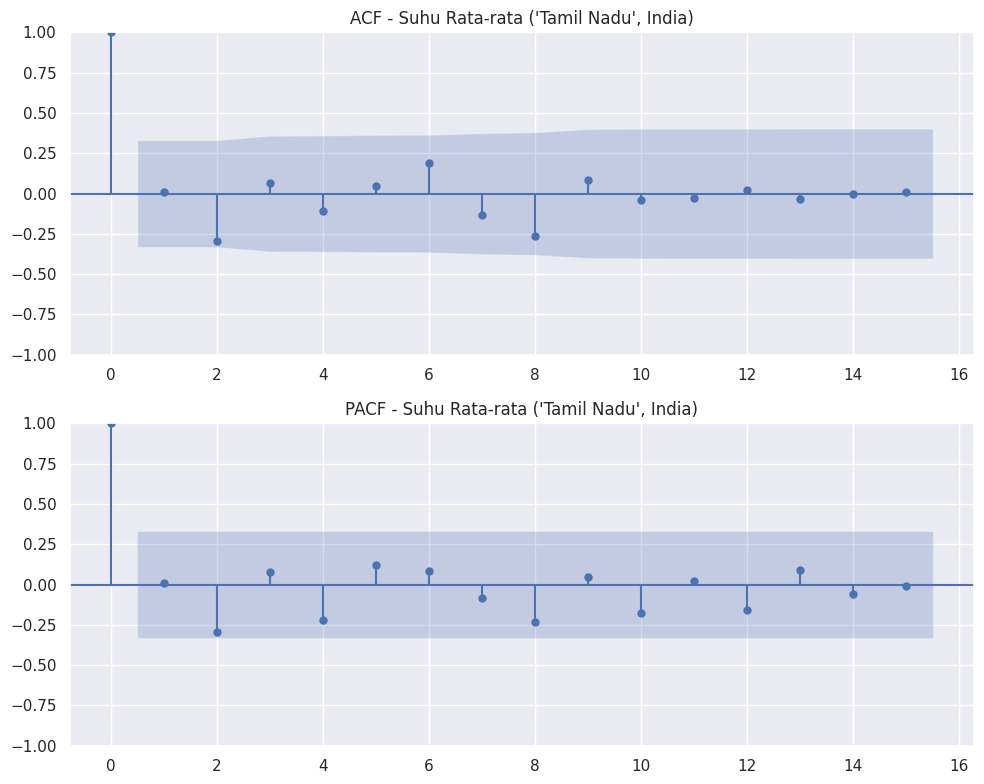

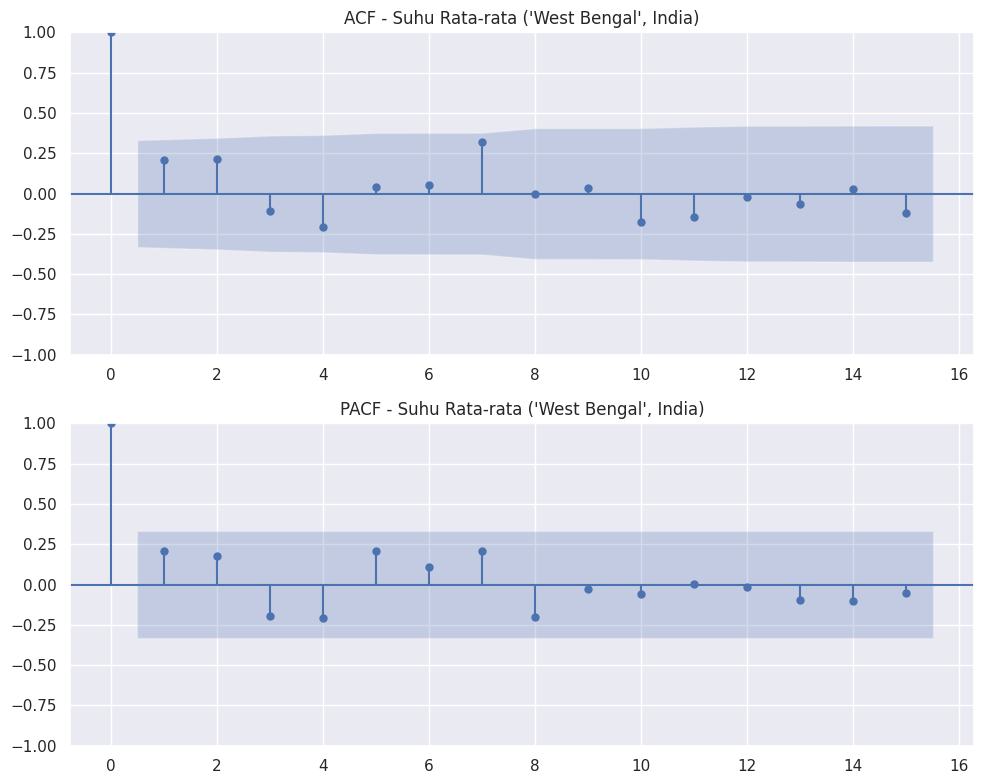

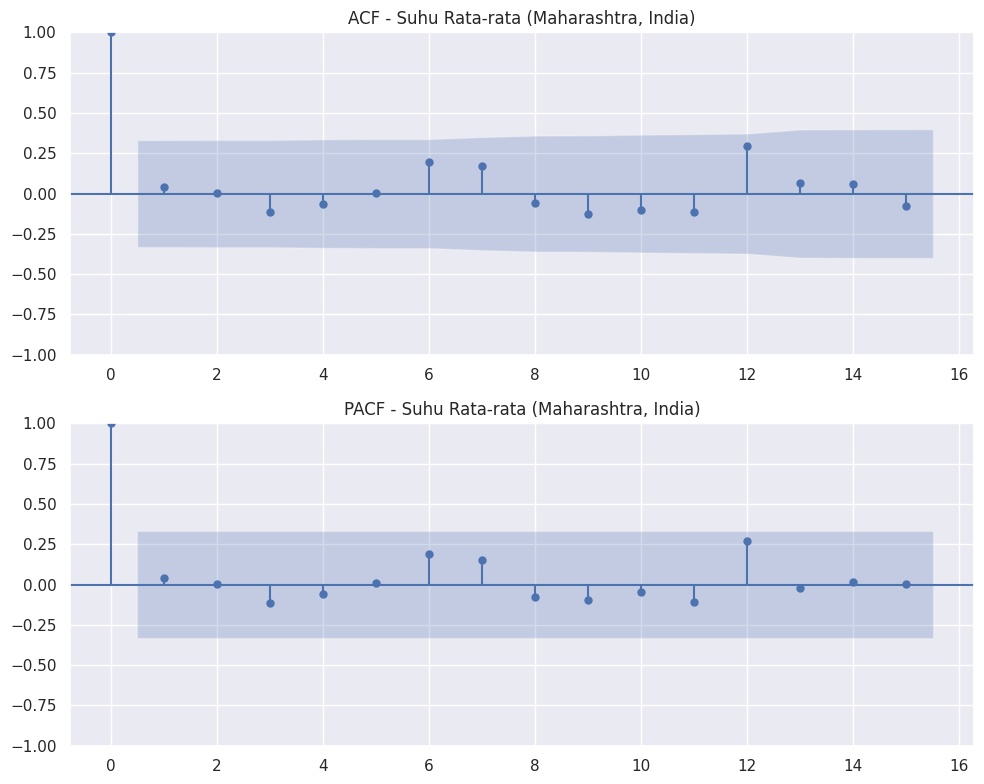

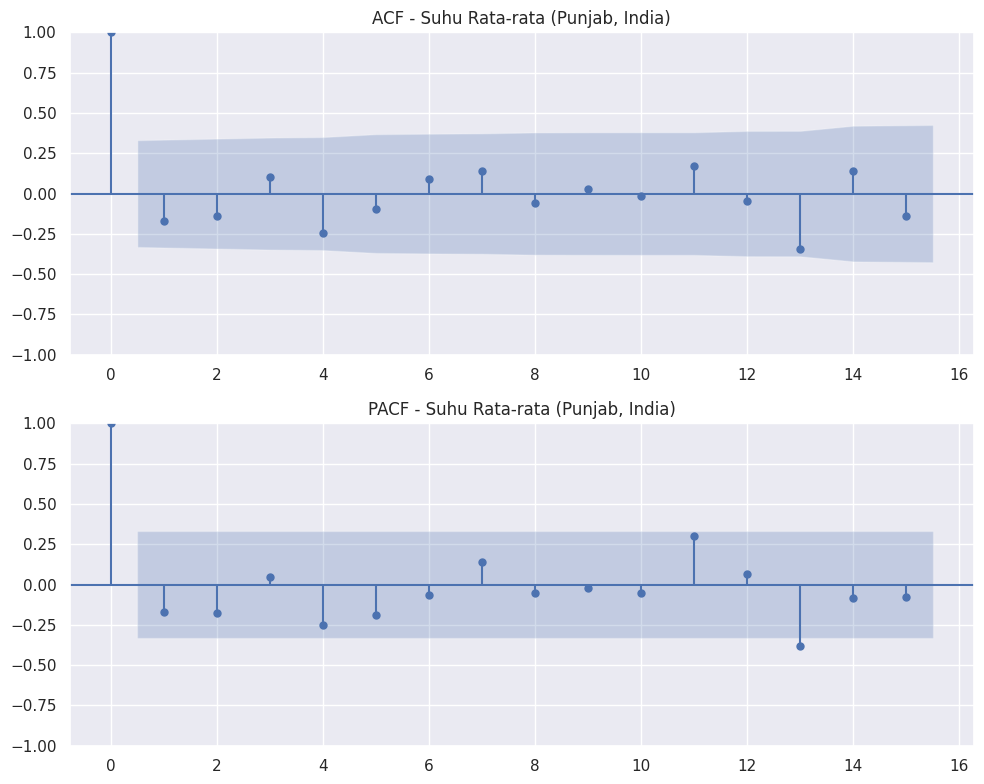

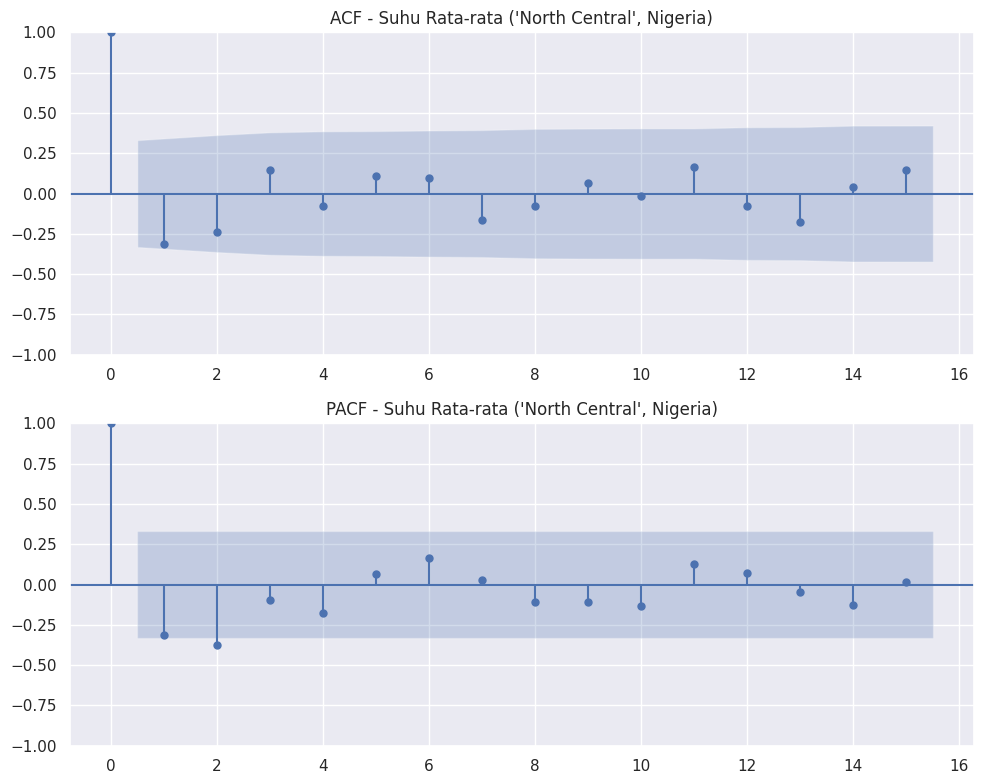

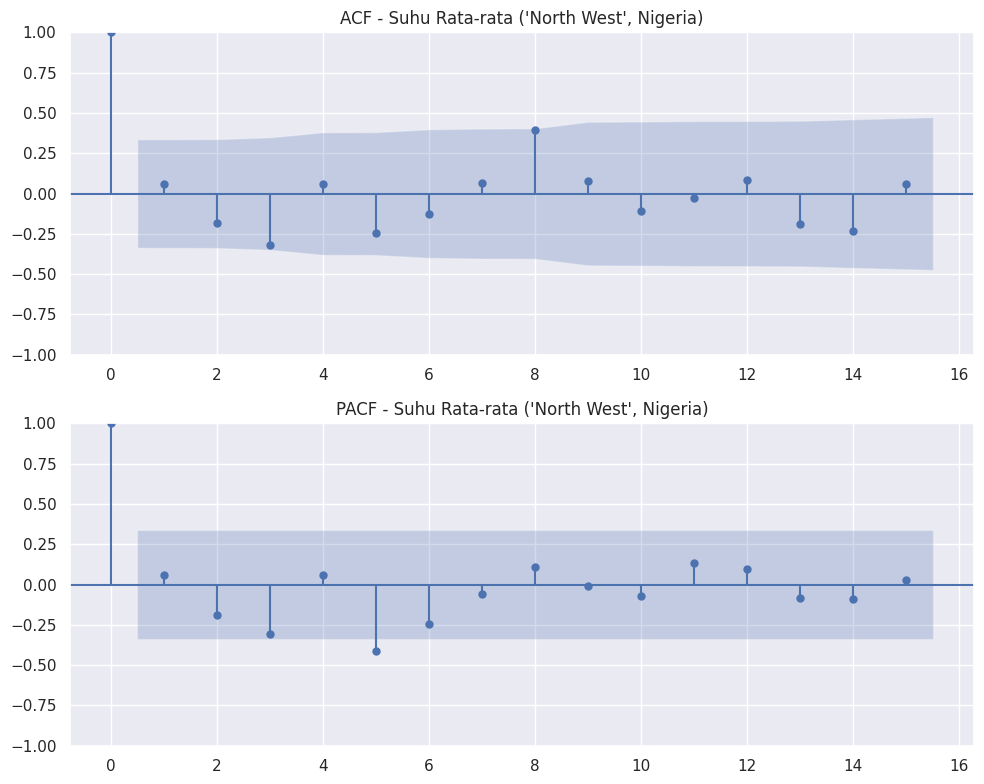

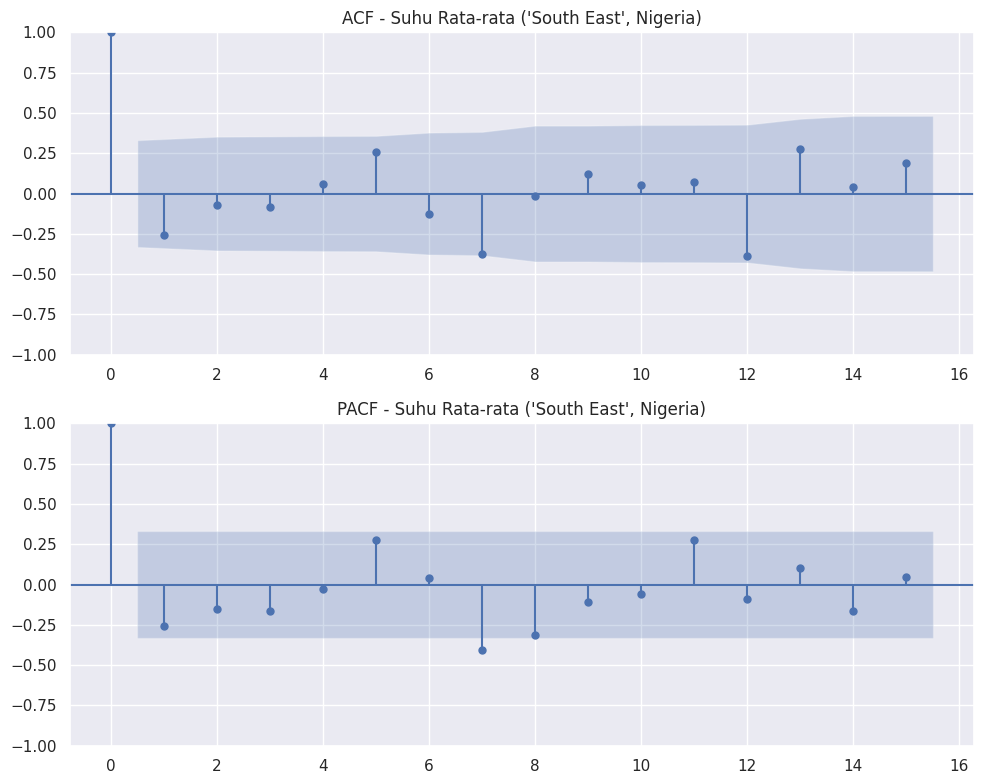

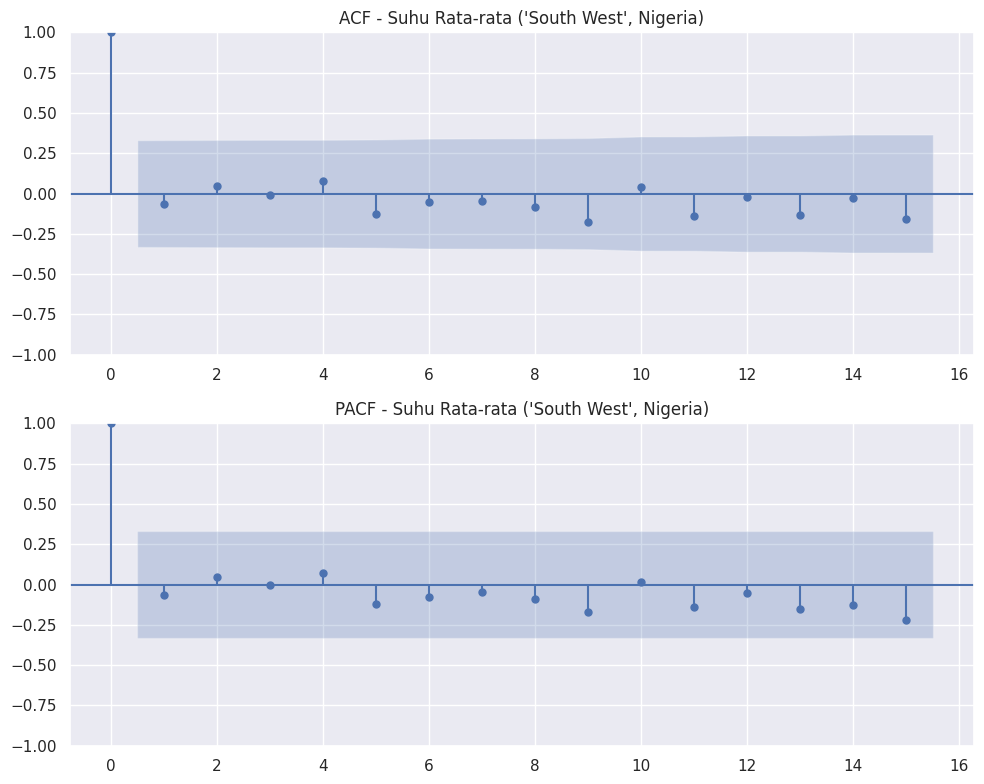

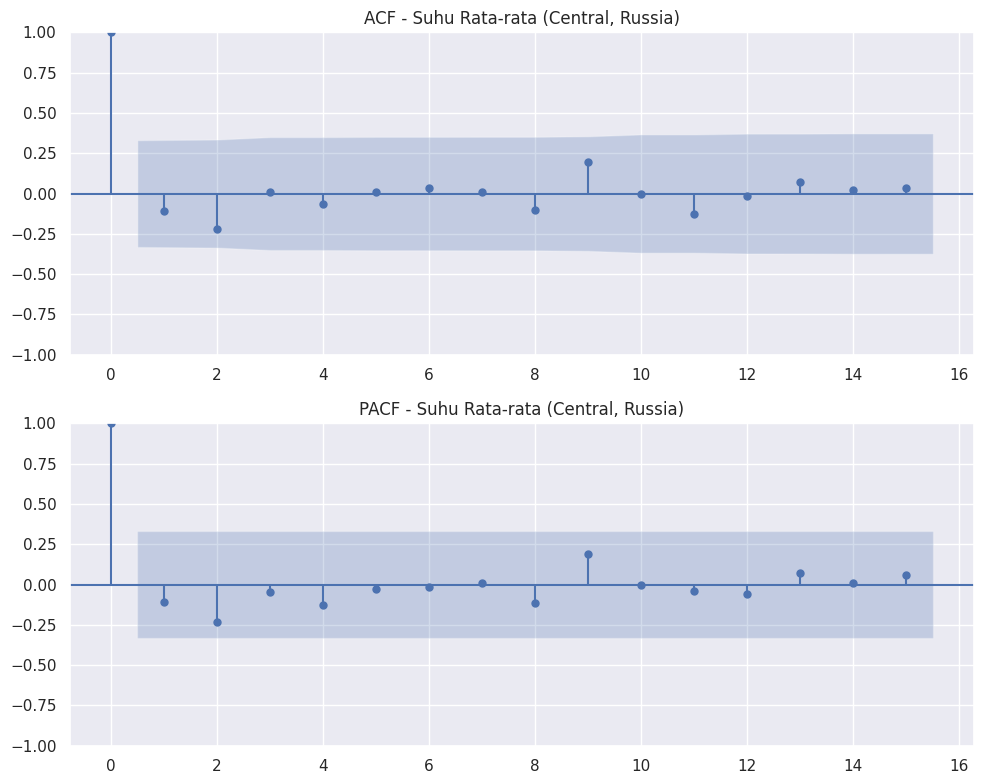

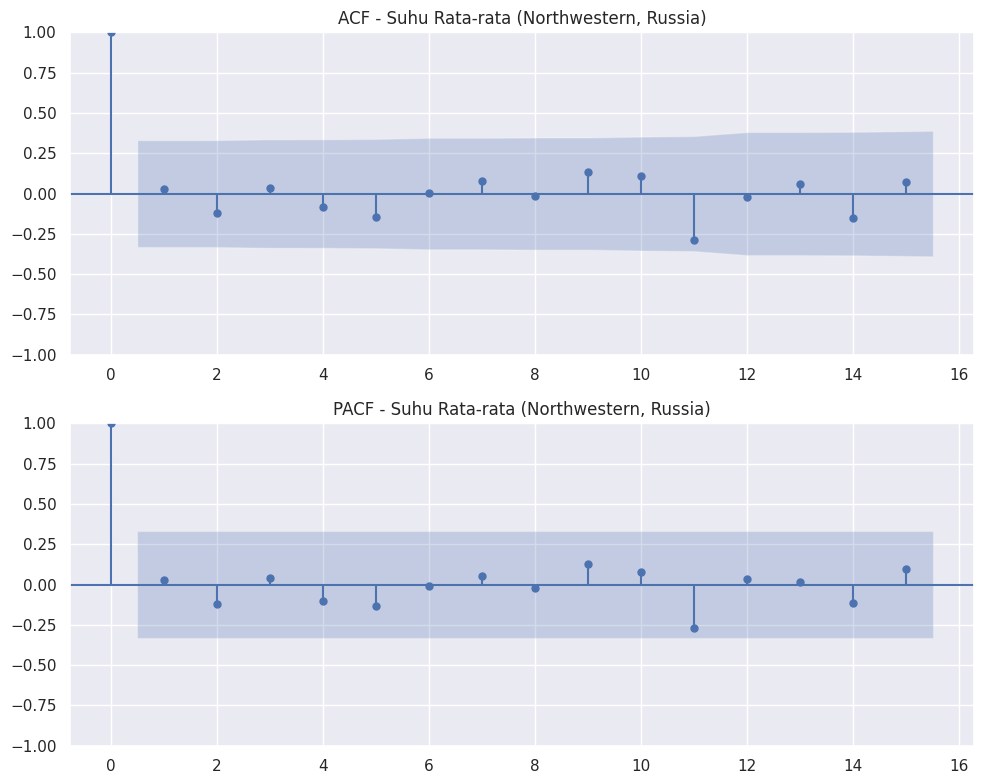

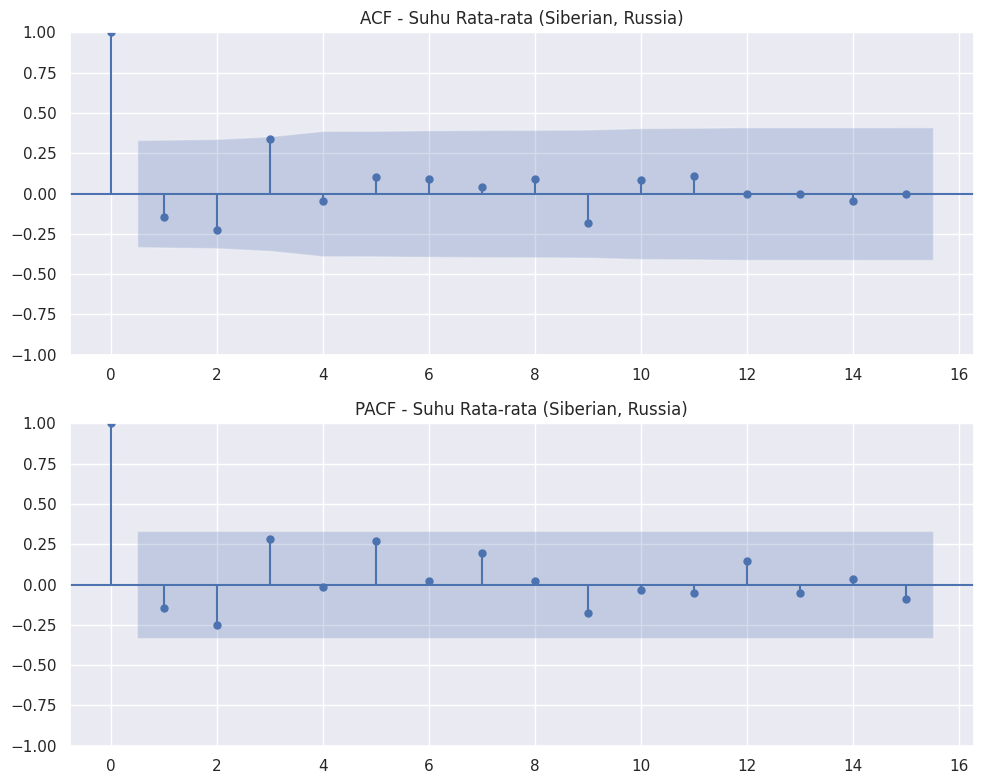

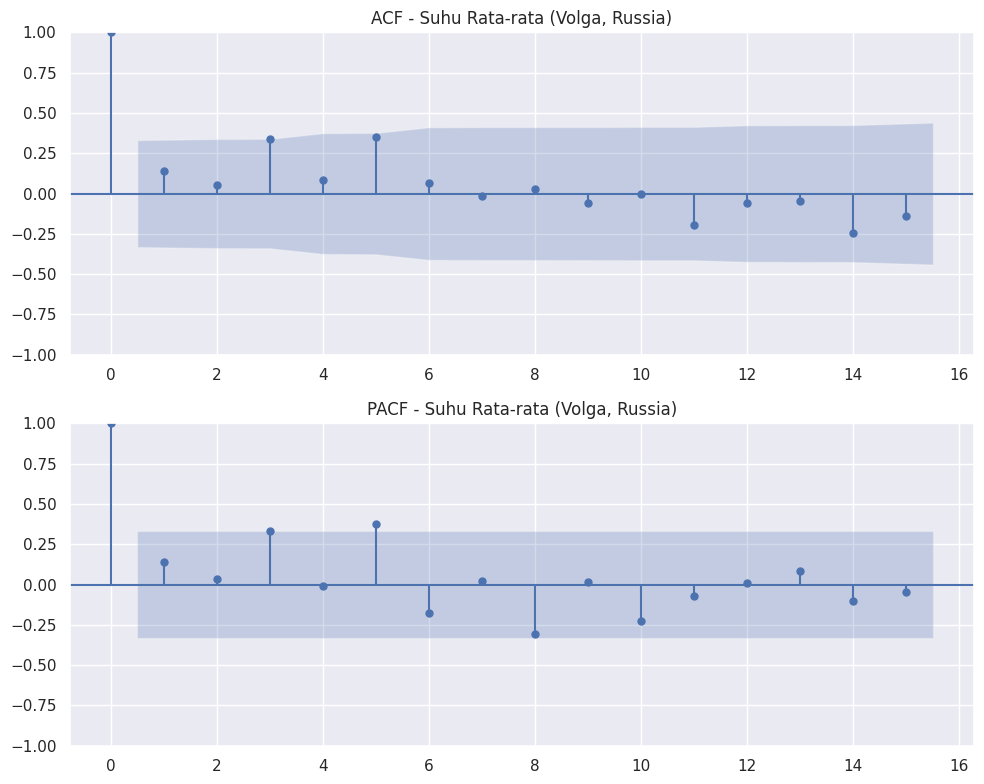

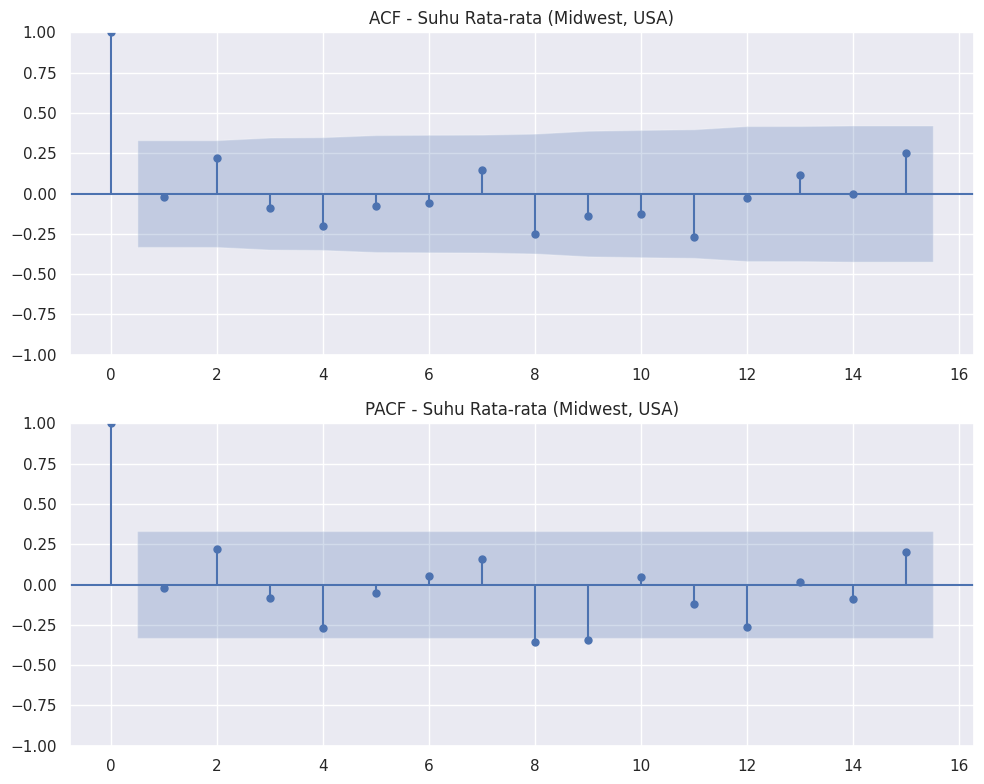

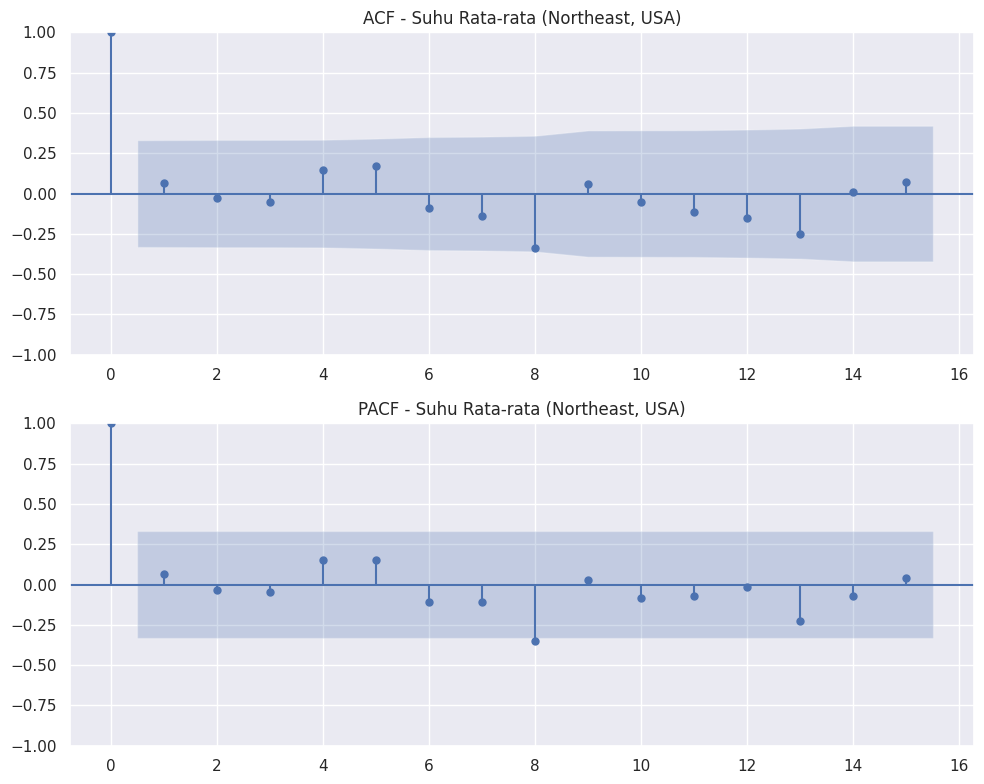

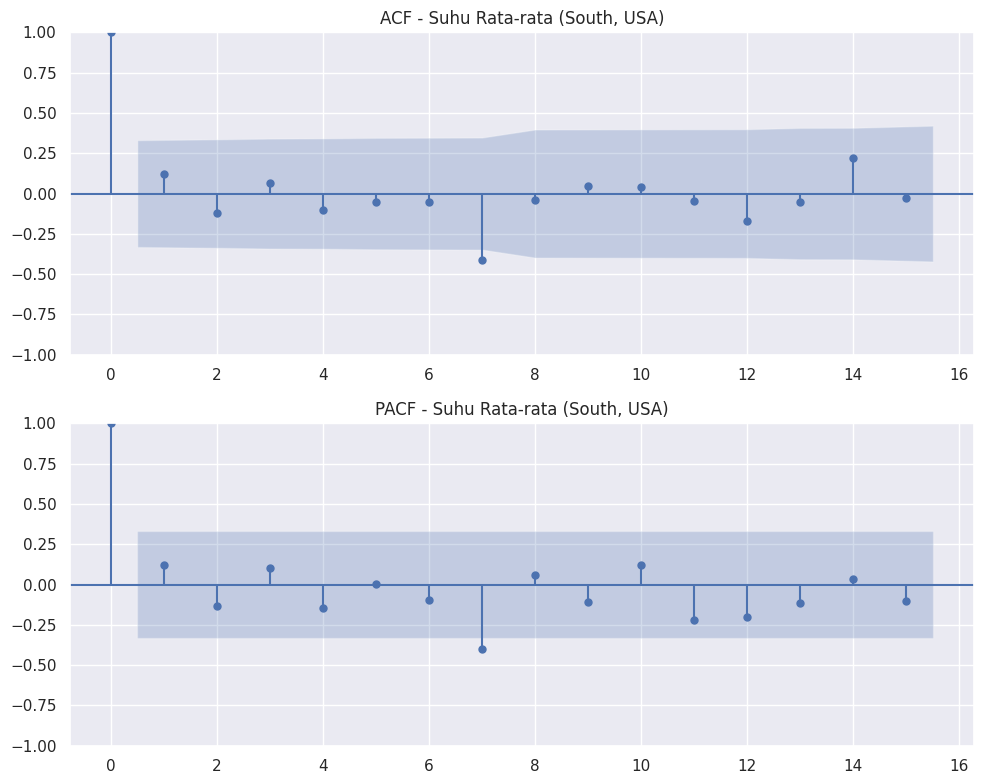

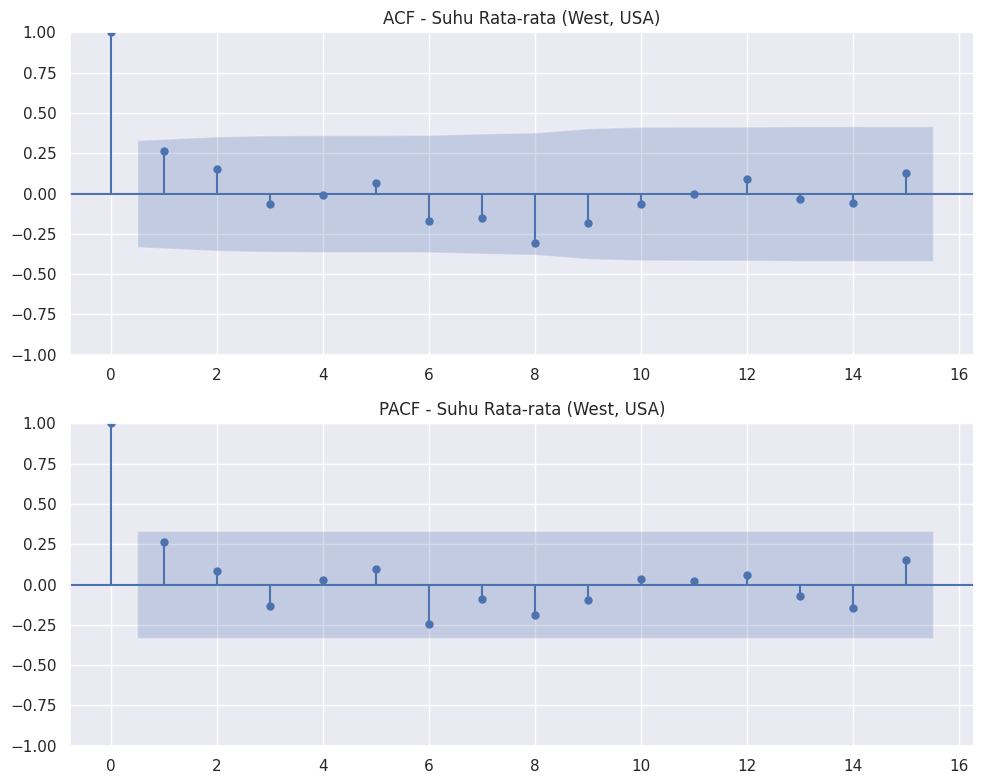

In [9]:
df_region_year = (
    df.groupby(["Nama_Negara", "Wilayah", "Tahun"], as_index=False)["Suhu_Rata_Rata_C"].mean()
)

for (country, region), df_sub in df_region_year.groupby(["Nama_Negara", "Wilayah"]):
    df_sub = df_sub.sort_values("Tahun")
    series = df_sub["Suhu_Rata_Rata_C"]

    # Create ACF and PACF plots
    fig, ax = plt.subplots(2, 1, figsize=(10, 8))
    plot_acf(series, lags=15, ax=ax[0], alpha=0.05)
    ax[0].set_title(f"ACF - Suhu Rata-rata ({region}, {country})")

    plot_pacf(series, lags=15, ax=ax[1], alpha=0.05, method='ywm')
    ax[1].set_title(f"PACF - Suhu Rata-rata ({region}, {country})")

    plt.tight_layout()
    plt.show()

Berdasarkan hasil percobaan yang telah dilakukan untuk mengetahui ketergantungan data dengan data-data di masa lampau dengan menggunakan teknik **ACF** dan **PACF**, ditemukan bahwa hubungan yang diperoleh sangat kecil. Secara umum, nilai berada di antara $+0.25$ dan $-0.25$ yang menunjukkan data berkorelasi lemah. Jika ditemukan kondisi demikian pada data time-series, ini mungkin disebabkan oleh data yang dihasilkan kurang natural atau masih bersifat sintetis sehingga data tidak memiliki pola yang bisa dipahami secara langsung jika dilihat dari aspek waktu ke waktu.

---

# 3. Data Preprocessing

Data preprocessing kali ini melibatkan tahapan-tahapan sebagai berikut:
- Data imputation - mengisi data yang kosong
- Encoding data - merubah data kategorikal menjadi data numerik
- Feature engineering
- Membagi dataset training dan testing

In [10]:
# Handle missing values
numeric_features = ['Total_Curah_Hujan_mm', 'Hasil_Panen_Ton_per_HA', 'Akses_Irigasi']
categorical_features = ['Jenis_Tanaman', 'Nama_Negara', 'Wilayah', 'Strategi_Adaptasi']

# Impute numeric features with median
numeric_imputer = SimpleImputer(strategy='median')
df[numeric_features] = numeric_imputer.fit_transform(df[numeric_features])

# Impute categorical with mode
cat_imputer = SimpleImputer(strategy='most_frequent')
df[categorical_features] = cat_imputer.fit_transform(df[categorical_features])

# Encode categorical variables
label_encoders = {}
for col in categorical_features:
    le = LabelEncoder()
    df[f'{col}_encoded'] = le.fit_transform(df[col])
    label_encoders[col] = le

# Feature engineering
df['CO2_per_Rainfall'] = df['Emisi_CO2_JT_Ton'] / (df['Total_Curah_Hujan_mm'] + 1)
df['Pesticide_per_Fertilizer'] = df['Penggunaan_Pestisida_KG_per_HA'] / (df['Penggunaan_Pupuk_KG_per_HA'] + 1)
df['Yield_Efficiency'] = df['Hasil_Panen_Ton_per_HA'] * df['Indeks_Kesehatan_Tanah'] / 100

# Prepare features and target
feature_cols = [col for col in df.columns if col not in ['Suhu_Rata_Rata_C', 'ID'] + categorical_features]
X = df[feature_cols]
y = df['Suhu_Rata_Rata_C']

# Split data
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=RANDOM_SEED)

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)


print('Preprocessing is done!')

Preprocessing is done!


# 4. Model Definition

Pembuatan arsitektur model dengan menyusunnya ke dalam sebuah model ensemble (*Regression Ensenble Model*) yang terdiri dari 4 model:
- LightGBM
- XGBoost
- Naive Drift
- Naive Seasonal
Keseluruhan model ini disusun dengan bantuan library **Darts** di Python yang memiliki tujuan utama untuk mengatasi data dalam bentuk time-series.

In [11]:
# Build Darts TimeSeries from the already preprocessed DataFrame
proj_root = Path.cwd().resolve().parent
if (proj_root / "darts" / "__init__.py").exists():
    sys.path.insert(0, str(proj_root))

# Prepare an explicit integer time axis for robustness
_df_ts = df.copy()
_df_ts["t"] = np.arange(len(_df_ts))

# Target series
series_target = TimeSeries.from_dataframe(
    _df_ts, time_col="t", value_cols=["Suhu_Rata_Rata_C"]
)

# Use engineered numeric columns as past covariates
# covar_cols = [c for c in feature_cols if c != "Suhu_Rata_Rata_C"]
covar_cols = list(feature_cols)
series_cov = TimeSeries.from_dataframe(
    _df_ts[["t"] + covar_cols], time_col="t", value_cols=covar_cols
)

# Scale target and covariates to stabilize training and avoid near-zero issues
scaler_y = Scaler()
scaler_x = Scaler()
series_target_s = scaler_y.fit_transform(series_target)
series_cov_s = scaler_x.fit_transform(series_cov)

# Temporal split that respects order
split_idx = int(len(_df_ts) * 0.8)
split_point = series_target_s.time_index[split_idx]
series_trg_train, series_trg_val = series_target_s.split_before(split_point)
series_cov_train, series_cov_val = series_cov_s.split_before(split_point)


# Simple heuristic to infer a reasonable seasonal period K for NaiveSeasonal using ACF
# Falls back to K=1 (last value) if no strong seasonal signal is detected
def infer_seasonal_period(values, max_k=24, min_k=2, threshold=0.3):
    x = np.asarray(values).reshape(-1)
    if len(x) < (min_k * 3):
        return 1, 0.0
    x = x - x.mean()
    best_k, best_corr = 1, 0.0
    # don't search beyond a third of the series length for stability
    upper = min(max_k, max(min_k, len(x) // 3))
    for k in range(min_k, upper + 1):
        # pearson correlation between series and lagged series
        try:
            corr = np.corrcoef(x[:-k], x[k:])[0, 1]
        except Exception:
            corr = 0.0
        if np.isfinite(corr) and corr > best_corr:
            best_corr = float(corr)
            best_k = int(k)
    if best_corr >= threshold:
        return best_k, best_corr
    return 1, best_corr


# Infer K on the original (unscaled) target to keep interpretability
K_guess, K_score = infer_seasonal_period(
    _df_ts["Suhu_Rata_Rata_C"].values,
    max_k=min(48, max(3, len(_df_ts) // 2)),
    min_k=2,
    threshold=0.3,
)
K_guess = 12
print(f"🔎 Inferred seasonal K = {K_guess} (ACF={K_score:.2f})")

# Define base forecasting models
# Use enough lags to cover at least one seasonal cycle if K_guess>1; cap to avoid overfitting on small data
lgbm_lags = max(12, int(K_guess))

chunk_length = 1

lgbm_base = LightGBMModel(
    lags=lgbm_lags * 2,
    lags_past_covariates=lgbm_lags,
    lags_future_covariates=None,
    output_chunk_length=chunk_length,
    random_state=RANDOM_SEED,
)

# XGBoost baseline with the same lag configuration as LightGBM
xgb_base = XGBModel(
    lags=lgbm_lags * 2,
    lags_past_covariates=lgbm_lags,
    lags_future_covariates=None,
    output_chunk_length=chunk_length,
    random_state=RANDOM_SEED,
)

# Naive baselines
naive_drift = NaiveDrift()
naive_seasonal = NaiveSeasonal(K=max(2, int(K_guess)))

base_models = [
    lgbm_base,
    xgb_base,
    naive_drift,
    naive_seasonal,
]

# Build RegressionEnsembleModel
# The meta-regressor will learn how to combine base models' predictions on the last n points of the training set.
model_ts = RegressionEnsembleModel(
    forecasting_models=base_models,
    regression_train_n_points=max(12, int(min(48, K_guess))),
)

🔎 Inferred seasonal K = 12 (ACF=0.02)


# 5. Model Training

In [12]:
# Fit on training slice (scaled)
model_ts.fit(
    series=series_trg_train,
    past_covariates=series_cov_train,
    verbose=False,
)

# Predict the length of the validation slice autoregressively (scaled)
pred_val_s = model_ts.predict(len(series_trg_val), past_covariates=series_cov_s)

# Inverse-transform predictions and validation for metric computation
pred_val = scaler_y.inverse_transform(pred_val_s)
series_trg_val_orig = scaler_y.inverse_transform(series_trg_val)

# Compute a robust MAPE on the validation horizon
mape_ts = float(
    np.mean(
        np.abs(
            (series_trg_val_orig.values() - pred_val.values())
            / np.maximum(np.abs(series_trg_val_orig.values()), 1e-6)
        )
    )
    * 100.0
)
print(f"📈 Darts RegressionEnsembleModel Validation MAPE: {mape_ts:.4f}%")

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.013378 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 37980
[LightGBM] [Info] Number of data points in the train set: 6364, number of used features: 216
[LightGBM] [Info] Start training from score 0.503462
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.013820 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 37980
[LightGBM] [Info] Number of data points in the train set: 6376, number of used features: 216
[LightGBM] [Info] Start training from score 0.503384
📈 Darts RegressionEnsembleModel Validation MAPE: 116.1996%


# 6. Model Validation & Testing

In [13]:
# Check predictions distribution for either Darts (pred_val) or sklearn (y_pred_val)
print("Validation Predictions:")

pred_arr = None
actual_arr = None

# Prefer Darts variables if present
if 'pred_val' in globals() or 'pred_val' in locals():
    try:
        pred_arr = np.asarray(pred_val.values()).reshape(-1)
        actual_arr = np.asarray(series_trg_val_orig.values()).reshape(-1)
    except Exception as e:
        print(f"⚠️ Unable to extract values from Darts TimeSeries: {e}")


if pred_arr is None or actual_arr is None:
    print("❌ No predictions found. Run either the Darts RegressionEnsembleModel section (producing pred_val) or the sklearn section (producing y_pred_val) first.")
else:
    print(f"Pred range: {pred_arr.min():.2f} to {pred_arr.max():.2f}")
    print(f"Pred mean: {pred_arr.mean():.2f}")
    print(f"Actual range: {actual_arr.min():.2f} to {actual_arr.max():.2f}")
    print(f"Actual mean: {actual_arr.mean():.2f}")

    # Check for near-zero predictions (causes huge MAPE)
    near_zero_mask = np.abs(pred_arr) < 0.1
    print(f"\n⚠️ Predictions near zero: {near_zero_mask.sum()} / {len(pred_arr)}")
    if near_zero_mask.sum() > 0:
        print(f"Actual values for near-zero predictions: {actual_arr[near_zero_mask]}")

Validation Predictions:
Pred range: -3.66 to 7.79
Pred mean: 2.04
Actual range: -4.93 to 35.00
Actual mean: 15.44

⚠️ Predictions near zero: 52 / 1600
Actual values for near-zero predictions: [ 3.77 17.44 19.59 11.94 24.75 17.46  9.86 10.36 13.43 29.85 29.76  1.49
 11.75 13.54 27.78 -0.77 23.34 26.57 20.94 -3.25 14.77 25.43 28.42 10.21
  5.39  1.18 16.81 17.87 20.95 25.15 27.31 19.   -2.37  3.82  2.64 11.7
 15.28  7.95  8.42 10.76 26.71  1.83 12.66 27.69  0.79 -1.24 18.4  -2.2
  0.52 25.3  16.47 23.62]


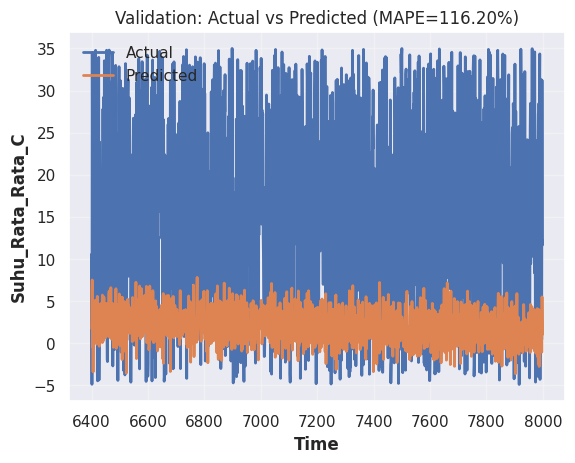

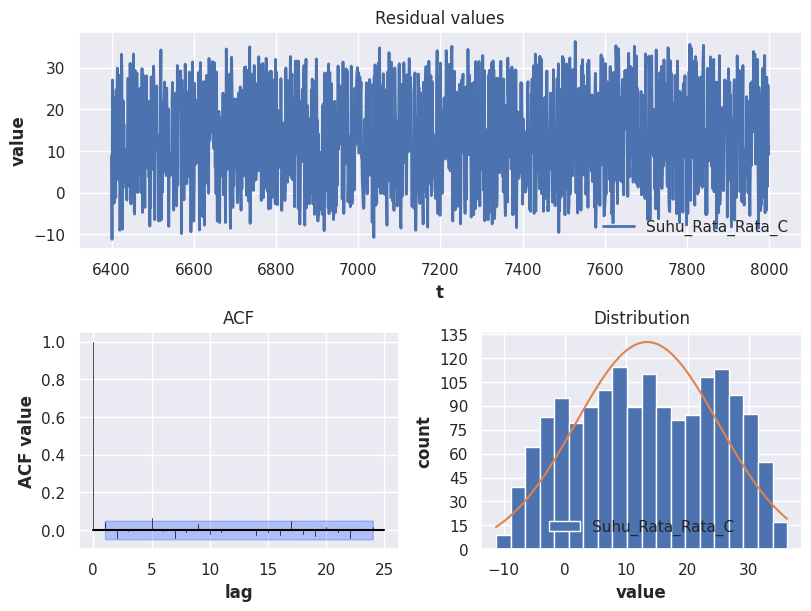

In [14]:
# Plot Actual vs Predicted (validation) using Darts plotting utilities

# Ensure we have TimeSeries predictions and actuals
try:
    series_trg_val_orig  # type: ignore[name-defined]
    pred_val  # type: ignore[name-defined]
except NameError:
    print("❌ No predictions to plot. Run the validation prediction cell first.")
    raise

# Robust MAPE computed from TimeSeries (handles zeros via epsilon clamp)
def _safe_mape_ts(actual_ts, pred_ts):
    try:
        # Align on intersection in time to avoid mismatched indices
        a = actual_ts.slice_intersect(pred_ts)
        p = pred_ts.slice_intersect(actual_ts)
        y_true = a.values().reshape(-1)
        y_pred = p.values().reshape(-1)
    except Exception:
        # Fallback: directly use provided series values
        y_true = np.asarray(series_trg_val_orig.values()).reshape(-1)
        y_pred = np.asarray(pred_val.values()).reshape(-1)
    eps = 1e-6
    return float(np.mean(np.abs((y_true - y_pred) / np.maximum(np.abs(y_true), eps))) * 100.0)

mape_plot = _safe_mape_ts(series_trg_val_orig, pred_val)

# Overlay plot using Darts' TimeSeries.plot
ax = series_trg_val_orig.plot(label="Actual")
pred_val.plot(ax=ax, label="Predicted")
ax.set_title(f"Validation: Actual vs Predicted (MAPE={mape_plot:.2f}%)")
ax.set_xlabel("Time")
ax.set_ylabel("Suhu_Rata_Rata_C")
ax.grid(True, alpha=0.3)
ax.legend()
plt.show()

# Optional: Residuals analysis using Darts utility (values, histogram, ACF)
try:
    residuals = series_trg_val_orig - pred_val
    plot_residuals_analysis(residuals)
except Exception as e:
    print(f"ℹ️ Residual analysis skipped: {e}")

# 6. Generate Predictions

Ini merupakan proses terakhir dalam pembuatan model pada data *time-series*. Model yang telah dilatih sebelumnya dan diuji menggunakan dataset uji pada saat training, kini diuji langsung dengan data yang beradi dari luar dataset yang asli. Model akan melakukan prediksi pada data uji terbaru dan output yang dihasilkan dari tahapan ini adalah sebuah file CSV yang berisi hasil prediksi data dengan metrik yang digunakan Mean Absolute Percentage Error (MAPE).

In [15]:
# Load test data
df_test = pd.read_csv(paths['test_csv'])

# Apply same preprocessing
df_test[numeric_features] = numeric_imputer.transform(df_test[numeric_features])
df_test[categorical_features] = cat_imputer.transform(df_test[categorical_features])

for col in categorical_features:
    df_test[f'{col}_encoded'] = label_encoders[col].transform(df_test[col])

# Feature engineering on test
df_test['CO2_per_Rainfall'] = df_test['Emisi_CO2_JT_Ton'] / (df_test['Total_Curah_Hujan_mm'] + 1)
df_test['Pesticide_per_Fertilizer'] = df_test['Penggunaan_Pestisida_KG_per_HA'] / (df_test['Penggunaan_Pupuk_KG_per_HA'] + 1)
df_test['Yield_Efficiency'] = df_test['Hasil_Panen_Ton_per_HA'] * df_test['Indeks_Kesehatan_Tanah'] / 100

X_test = df_test[feature_cols]
X_test_scaled = scaler.transform(X_test)  # kept in case you also run the sklearn path

# --- Darts prediction path ---
# Build a future time index for test and extend covariates into the future so models with lags_past_covariates can predict autoregressively
try:
    # Ensure we have the training _df_ts and covariate/Scaler objects from the Darts section
    if '_df_ts' not in globals() and '_df_ts' not in locals():
        raise RuntimeError("Darts training variables not found. Run the Darts training cell first.")
    if 'scaler_x' not in globals() and 'scaler_x' not in locals():
        raise RuntimeError("Darts scalers not found. Run the Darts training cell first.")

    # Create future time index continuing after the last training step
    df_test_ts = df_test.copy()
    start_t = int(_df_ts['t'].iloc[-1]) + 1 if 't' in _df_ts.columns else len(_df_ts)
    df_test_ts['t'] = np.arange(start_t, start_t + len(df_test))

    # Build future covariates TimeSeries and append to training covariates, then scale consistently
    covar_cols = [c for c in feature_cols if c != 'Suhu_Rata_Rata_C']
    series_cov_future = TimeSeries.from_dataframe(df_test_ts[['t'] + covar_cols], time_col='t', value_cols=covar_cols)
    series_cov_full = series_cov.append(series_cov_future)
    series_cov_full_s = scaler_x.transform(series_cov_full)

    # Predict n steps equal to test length using the SAME training target series used at fit to ensure aligned time axis
    n_test = len(df_test)
    pred_test_s = model_ts.predict(n_test, series=series_trg_train, past_covariates=series_cov_full_s)
    pred_test = scaler_y.inverse_transform(pred_test_s)
    predictions = pred_test.values().reshape(-1)

    # Optional sanity clamp to plausible physical range based on train stats
    y_min, y_max = df['Suhu_Rata_Rata_C'].quantile(0.01), df['Suhu_Rata_Rata_C'].quantile(0.99)
    predictions = np.clip(predictions, y_min - 1.0, y_max + 1.0)
except Exception as e:
    # Fallback or explicit error to guide the user
    raise RuntimeError(f"Failed to generate Darts predictions. Ensure the Darts training cell ran successfully. Details: {e}")

# Save submission
submission = pd.DataFrame({
    'ID': df_test['ID'],
    'Suhu_Rata_Rata_C': predictions
})
submission_path = f"{paths['save_dir']}/submission.csv"
submission.to_csv(submission_path, index=False)
print(f"✅ Submission saved to {submission_path}")

✅ Submission saved to /kaggle/working/submission.csv
